# Audit: data construction and robustness of the commune density–concentration result

Preliminary results (`analysis_communes.ipynb`): little or no density–concentration association in 2002 once very
small communes are excluded, a positive one in 2022, stronger for larger electorates. This notebook audits the data
construction and re-estimates the relationship under alternative, pre-specified choices:

| § | check |
|---|---|
| 1 | failed commune scrapes |
| 2 | why observations leave `main_sample` (one reason per observation) |
| 3 | boundary-change rule: **strict** (`main_sample`) vs **broad** cross-sectional sample |
| 4 | which population measure enters the 2002 density |
| 5 | density validation, Paris / Lyon / Marseille |
| 6 | small electorates, extreme values and the finite-electorate correction |
| 7–8 | electorate-size thresholds; vote-weighted robustness |
| 9 | density deciles |
| 10 | within-département (fixed-effects) association |
| 11 | pooled year × density interaction |
| Summary | computed summary of everything above |

**Outcomes.** `HHI` (observed vote concentration) is the main measure; `HHI_corrected` (finite-electorate corrected
HHI) checks whether results come from the mechanical concentration of small electorates — it estimates underlying
concentration, while HHI describes the realised result, so neither replaces the other; `CENP` is kept as a
continuity and robustness check (supplementary normalised measure, linked to the ABM). None of them identifies
strategic voting on its own.

Rules: 2002 and 2022 are **two separate cross-sections**, not a matched panel; all thresholds and samples are reported
side by side, none is chosen for its result; everything is descriptive.

Outputs (`data/processed/audit_corrected/`): `audit_cenp_density_by_threshold.csv` and `audit_scorecard.csv` (CENP,
unchanged format), `audit_hhi_density_by_threshold.csv` and `audit_scorecard_hhi.csv` (HHI and corrected HHI, with an
`outcome` column), `audit_sample_flags.csv`. Nothing is downloaded: pages are read from the HTML cache only.

In [1]:
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from scipy import stats

from svgeo import communes as com
from svgeo.analysis import association_stats, fe_stats, show_plot, stats_by_threshold
from svgeo.config import (ARRONDISSEMENTS, AUDIT_DIR, COMMUNE_DENSITY, COMMUNE_FAILURES, COMMUNE_RESULTS,
                          EXPECTED_K, INSEE_COMMUNES, INSEE_COMMUNES_META, PLM, YEARS)
from svgeo.utils import norm_text, read_csv, report
from svgeo.web import commune_pages

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)
commune_pages.offline = True  # cached pages only

ALPHA = 0.05
OUTCOMES = ["HHI", "HHI_corrected", "CENP"]  # HHI main; corrected HHI for small electorates; CENP continuity
AUDIT_DIR.mkdir(parents=True, exist_ok=True)

results = read_csv(COMMUNE_RESULTS)
merged = read_csv(COMMUNE_DENSITY)
main = merged[merged["main_sample"]].copy()
scrape_failures = pd.concat([read_csv(COMMUNE_FAILURES[y]) for y in YEARS], ignore_index=True)

insee_raw = pd.read_csv(INSEE_COMMUNES, sep=";", dtype={"CODGEO": str}, encoding="utf-8",
                        usecols=["CODGEO", "P22_POP", "P06_POP", "D99_POP", "SUPERF"])
insee = (insee_raw[~insee_raw["CODGEO"].isin(ARRONDISSEMENTS)]
         .rename(columns={"CODGEO": "commune_code", "SUPERF": "surface_km2"}))
# Commune names of the INSEE file (its metadata lists every CODGEO with its name)
insee_names = (pd.read_csv(INSEE_COMMUNES_META, sep=";", dtype=str, encoding="utf-8")
                 .query("COD_VAR == 'CODGEO'")[["COD_MOD", "LIB_MOD"]]
                 .rename(columns={"COD_MOD": "commune_code", "LIB_MOD": "insee_name"})
                 .drop_duplicates("commune_code"))

/opt/anaconda3/lib/python3.11/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


## 1. Failed commune scrapes

The failure files list the pages still failing **after the retries**. "Expected communes" = commune URLs found on the
département / alphabetical index pages: set `REBUILD_DISCOVERY_FROM_CACHE = True` to rebuild that list from the HTML
cache (a few minutes); otherwise "parsed + recorded commune failures" is used. `no communes` entries are territories
whose results are not published by commune. Two further checks: pages read correctly but reporting **0 expressed
votes**, and INSEE communes without any election page.

In [2]:
REBUILD_DISCOVERY_FROM_CACHE = False

with pd.option_context("display.max_colwidth", 120):
    display(scrape_failures.sort_values(["year", "level", "department_code"]).reset_index(drop=True))

scrape_rows, not_parsed = [], {}
for year in YEARS:
    parsed = set(results.loc[results["year"] == year, "commune_code"])
    f = scrape_failures[scrape_failures["year"] == year]
    commune_fail = f[f["level"] == "commune"]
    if REBUILD_DISCOVERY_FROM_CACHE:
        urls = com.discover_all_communes(year, com.load_department_urls(year), verbose=False)[0]
        expected, source = set(urls["commune_code"]), "commune URLs rebuilt from the HTML cache"
        not_parsed[year] = urls[~urls["commune_code"].isin(parsed)]
    else:
        expected = parsed | set(commune_fail["commune_code"].dropna())
        source = "parsed + recorded commune failures"
    scrape_rows.append({
        "year": year,
        "expected_communes": len(expected),
        "scraped_communes": len(expected & parsed),
        "failed_communes": len(expected - parsed),
        "pct_recovered": round(100 * len(expected & parsed) / len(expected), 3),
        "recorded_commune_page_failures": len(commune_fail),
        "failed_departement_or_index_pages": int(f["level"].isin(["department", "index page"]).sum()),
        "territories_without_commune_pages": int((f["level"] == "no communes").sum()),
        "expected_from": source,
    })
scrape_summary = pd.DataFrame(scrape_rows).set_index("year")
display(scrape_summary)
for year, df in not_parsed.items():
    report(f"{year}: every discovered commune URL has parsed results", df.empty, df)

,year,level,department_code,commune_code,name,url,error
0,2002,no communes,975,NaN,Saint-Pierre-et-Miquelon,https://www.archives-resultats-elections.interieur.gouv.fr/resultats/presidentielle_2002/000/975/975.php,no commune link found
1,2002,no communes,986,NaN,Wallis-et-Futuna,https://www.archives-resultats-elections.interieur.gouv.fr/resultats/presidentielle_2002/000/986/986.php,no commune link found
2,2002,no communes,987,NaN,Polynésie française,https://www.archives-resultats-elections.interieur.gouv.fr/resultats/presidentielle_2002/000/987/987.php,no commune link found
3,2002,no communes,988,NaN,Nouvelle-Calédonie,https://www.archives-resultats-elections.interieur.gouv.fr/resultats/presidentielle_2002/000/988/988.php,no commune link found
4,2022,no communes,986,NaN,Wallis-et-Futuna,https://www.archives-resultats-elections.interieur.gouv.fr/resultats/presidentielle-2022/000/986/index.php,no commune link found
5,2022,no communes,ZZ,NaN,Français établis hors de France,https://www.archives-resultats-elections.interieur.gouv.fr/resultats/presidentielle-2022/000/099/index.php,no commune link found


,expected_communes,scraped_communes,failed_communes,pct_recovered,recorded_commune_page_failures,failed_departement_or_index_pages,territories_without_commune_pages,expected_from
year,,,,,,,,
2002,36674,36674,0,100.0,0,0,4,parsed + recorded commune failures
2022,35034,35034,0,100.0,0,0,2,parsed + recorded commune failures


In [3]:
# Pages read correctly but unusable: 0 expressed votes (every ballot blank/null — typically results annulled)
urls_by_commune = results.drop_duplicates(["year", "commune_code"])[["year", "commune_code", "source_url"]]
zero_expressed = (merged.loc[merged["expressed"] <= 0, ["year", "department_code", "commune_code", "commune_name",
                                                        "registered", "voters", "blank_null", "expressed"]]
                  .merge(urls_by_commune, on=["year", "commune_code"], how="left"))
print(f"Communes with 0 expressed votes: {len(zero_expressed)}")
with pd.option_context("display.max_colwidth", 120):
    display(zero_expressed)

for year in YEARS:
    missing = (insee[~insee["commune_code"].isin(results.loc[results["year"] == year, "commune_code"])]
               .merge(insee_names, on="commune_code", how="left"))
    print(f"\n{year}: INSEE communes without election results: {len(missing)} (codes created after {year}, ...)")
    with pd.option_context("display.max_rows", 100):
        display(missing[["commune_code", "insee_name", "D99_POP", "P06_POP", "P22_POP", "surface_km2"]])

Communes with 0 expressed votes: 14


,year,department_code,commune_code,commune_name,registered,voters,blank_null,expressed,source_url
0,2022,02,02078,Besmé,113,93,93,0,https://www.archives-resultats-elections.interieur.gouv.fr/resultats/presidentielle-2022/032/002/002078.php
1,2022,02,02093,Blérancourt,867,640,640,0,https://www.archives-resultats-elections.interieur.gouv.fr/resultats/presidentielle-2022/032/002/002093.php
2,2022,24,24130,Condat-sur-Vézère,689,550,550,0,https://www.archives-resultats-elections.interieur.gouv.fr/resultats/presidentielle-2022/075/024/024130.php
3,2022,2A,2A065,Cargèse,997,598,598,0,https://www.archives-resultats-elections.interieur.gouv.fr/resultats/presidentielle-2022/094/02A/02A065.php
4,2022,38,38211,Lieudieu,259,197,197,0,https://www.archives-resultats-elections.interieur.gouv.fr/resultats/presidentielle-2022/084/038/038211.php
5,2022,42,42152,Nandax,432,343,343,0,https://www.archives-resultats-elections.interieur.gouv.fr/resultats/presidentielle-2022/084/042/042152.php
6,2022,60,60316,Hodenc-l'Evêque,209,167,167,0,https://www.archives-resultats-elections.interieur.gouv.fr/resultats/presidentielle-2022/032/060/060316.php
7,2022,60,60391,Maysel,203,158,158,0,https://www.archives-resultats-elections.interieur.gouv.fr/resultats/presidentielle-2022/032/060/060391.php
8,2022,60,60504,Ponchon,747,606,606,0,https://www.archives-resultats-elections.interieur.gouv.fr/resultats/presidentielle-2022/032/060/060504.php
9,2022,62,62494,Léchelle,41,30,30,0,https://www.archives-resultats-elections.interieur.gouv.fr/resultats/presidentielle-2022/032/062/062494.php



2002: INSEE communes without election results: 29 (codes created after 2002, ...)


,commune_code,insee_name,D99_POP,P06_POP,P22_POP,surface_km2
0,14482,Ouézy,199,233,232,4.550000
1,22201,Plévenon,721,665,757,13.730000
2,26020,La Répara-Auriples,230,216,255,15.030000
3,31300,Lieoux,126,123,126,5.830000
4,35317,Saint-Symphorien,416,506,613,7.910000
5,47163,Mauvezin-sur-Gupie,429,452,611,15.800000
6,51201,Cuisles,137,139,127,2.770000
7,52033,Avrecourt,129,139,113,7.630000
8,52124,Chézeaux,102,72,78,10.730000
9,52266,Laneuville-à-Rémy,51,57,66,5.960000



2022: INSEE communes without election results: 18 (codes created after 2022, ...)


,commune_code,insee_name,D99_POP,P06_POP,P22_POP,surface_km2
0,12218,Conques-en-Rouergue,1685,1679,1555,106.23
1,14581,Aurseulles,1745,1913,1908,46.00
2,15031,Celles,239,235,217,18.35
3,15035,Chalinargues,433,435,311,27.55
4,15047,Chavagnac,94,102,91,16.58
5,15171,Sainte-Anastasie,167,162,124,15.88
6,27676,Les Trois Lacs,1523,1688,1748,36.53
7,49126,Orée d'Anjou,12296,14189,16975,156.34
8,55039,Beaumont-en-Verdunois,0,0,0,7.87
9,55050,Bezonvaux,0,0,0,9.23


**Cross-sections, not a panel.** A commune missing in one year (failed scrape, annulled results, no INSEE match) is
excluded from that year only; restricting both years to a common set of communes would discard valid information.

In [4]:
codes_in_main = {year: set(main.loc[main["year"] == year, "commune_code"]) for year in YEARS}
print("main_sample communes: only in 2002:", len(codes_in_main[2002] - codes_in_main[2022]),
      "| only in 2022:", len(codes_in_main[2022] - codes_in_main[2002]),
      "| in both years:", len(codes_in_main[2002] & codes_in_main[2022]), "— all kept in their own year")

main_sample communes: only in 2002: 255 | only in 2022: 786 | in both years: 33326 — all kept in their own year


## 2. Why observations leave `main_sample`

`main_sample` = metropolitan **and** matched to INSEE **and** finite `log_density` **and** CENP available **and not**
`possible_boundary_change`. Each observation receives the **first** reason that applies, in the order below, so
reasons add up to the total. Unmatched codes are split using the 2022 results as a diagnostic: a 2002 code absent from
the 2022 results disappeared in a merger between 2002 and 2022; a code present in the 2022 results but not in the
INSEE file disappeared **after** the 2022 election (the INSEE geography is later than 2022 — see §3). The reasons are
checked to reproduce `main_sample` exactly.

In [5]:
def name_key(name):
    # commune name normalised for comparison: accents, case, punctuation, St/Ste, article in parentheses
    s = str(name).replace("œ", "oe").replace("Œ", "OE").replace("æ", "ae").replace("Æ", "AE")
    m = re.fullmatch(r"(.*?)\s*\((l'|l’|le|la|les)\)\s*", s, flags=re.I)
    if m:
        s = f"{m.group(2)} {m.group(1)}"
    s = norm_text(s)
    s = re.sub(r"\bste\b", "sainte", s)
    s = re.sub(r"\bst\b", "saint", s)
    return s.replace(" ", "")


audit = merged.merge(insee_names, on="commune_code", how="left", validate="many_to_one")
audit["valid_density"] = (audit["insee_match"] & (audit["density_population"] > 0) & (audit["surface_km2"] > 0)
                          & np.isfinite(audit["log_density"]))
audit["ratio_low"] = audit["insee_match"] & (audit["registered_to_population"] < 0.4)
audit["ratio_high"] = audit["insee_match"] & (audit["registered_to_population"] > 1.2)
audit["name_mismatch"] = audit["insee_match"] & (audit["commune_name"].map(name_key) != audit["insee_name"].map(name_key))

unmatched_deps = set(map(tuple, audit.loc[audit["metropolitan"] & ~audit["insee_match"],
                                          ["year", "department_code"]].itertuples(index=False)))
audit["dep_has_unmatched"] = [(y, d) in unmatched_deps for y, d in zip(audit["year"], audit["department_code"])]
codes_2022 = set(results.loc[results["year"] == 2022, "commune_code"])

RETAINED = "retained (main_sample)"
EXCLUSION_RULES = [
    ("overseas", ~audit["metropolitan"]),
    ("0 expressed votes (all ballots blank/null)", audit["expressed"].fillna(0) <= 0),
    ("indices missing (other)", audit["CENP"].isna()),
    ("Paris/Lyon/Marseille arrondissement code", audit["commune_code"].isin(ARRONDISSEMENTS)),
    ("no INSEE match: 2002 code absent from 2022 results (merger 2002–2022)",
     ~audit["insee_match"] & (audit["year"] == 2002) & ~audit["commune_code"].isin(codes_2022)),
    ("no INSEE match: code in 2022 results, not in INSEE file (merger after 2022)", ~audit["insee_match"]),
    ("INSEE population missing", audit["population"].isna()),
    ("INSEE population = 0", audit["population"] <= 0),
    ("INSEE surface missing or <= 0", ~(audit["surface_km2"] > 0)),
    ("non-finite log density (other)", ~np.isfinite(audit["log_density"])),
    ("boundary flag: registered/population < 0.4", audit["registered_to_population"] < 0.4),
    ("boundary flag: registered/population > 1.2", audit["registered_to_population"] > 1.2),
]
audit["exclusion_reason"] = np.select([cond.to_numpy(dtype=bool) for _, cond in EXCLUSION_RULES],
                                      [label for label, _ in EXCLUSION_RULES], default=RETAINED)

mismatch = (audit["exclusion_reason"] == RETAINED) != audit["main_sample"]
report("exclusion reasons reproduce main_sample exactly", not mismatch.any(),
       audit.loc[mismatch, ["year", "commune_code", "commune_name", "exclusion_reason", "main_sample"]])

reason_order = [label for label, _ in EXCLUSION_RULES] + [RETAINED]
exclusion_counts = pd.crosstab(audit["exclusion_reason"], audit["year"]).reindex(reason_order, fill_value=0)
metro_totals = audit[audit["metropolitan"]].groupby("year").size()
exclusion_pct_metro = (exclusion_counts.drop(index="overseas") / metro_totals * 100).round(2)
print("Observations by primary exclusion reason:")
display(pd.concat({"n": exclusion_counts, "% of metropolitan": exclusion_pct_metro}, axis=1))

metro = audit[audit["metropolitan"]]
sample_counts = metro.groupby("year").agg(
    metropolitan_election_obs=("commune_code", "size"), with_CENP=("CENP", lambda s: int(s.notna().sum())),
    insee_matched=("insee_match", "sum"), valid_density=("valid_density", "sum"), main_sample=("main_sample", "sum"))
sample_counts["pct_retained"] = (100 * sample_counts["main_sample"] / sample_counts["metropolitan_election_obs"]).round(2)
display(sample_counts)

print("Non-exclusive flags among metropolitan observations:")
display(metro.assign(no_insee_match=~metro["insee_match"], zero_expressed=metro["expressed"].fillna(0) <= 0,
                     invalid_density=~metro["valid_density"])
        .groupby("year")[["zero_expressed", "no_insee_match", "invalid_density", "ratio_low", "ratio_high",
                          "possible_boundary_change", "name_mismatch"]].sum())

print("Are the excluded observations different? (median log density / expressed, mean CENP by reason)")
display(metro.groupby(["year", "exclusion_reason"]).agg(
    n=("commune_code", "size"), median_log_density=("log_density", "median"),
    median_expressed=("expressed", "median"), mean_CENP=("CENP", "mean")).round(3))

[OK] exclusion reasons reproduce main_sample exactly
Observations by primary exclusion reason:


n        % of metropolitan       
year                                                 2002   2022              2002   2022
exclusion_reason                                                                         
overseas                                              115    214               NaN    NaN
0 expressed votes (all ballots blank/null)              0     13              0.00   0.04
indices missing (other)                                 0      0              0.00   0.00
Paris/Lyon/Marseille arrondissement code                0      0              0.00   0.00
no INSEE match: 2002 code absent from 2022 resu...   1750      0              4.79   0.00
no INSEE match: code in 2022 results, not in IN...     92     92              0.25   0.26
INSEE population missing                                0      0              0.00   0.00
INSEE population = 0                                    0      0              0.00   0.00
INSEE surface missing or <= 0                           0      0              0.00   0.00
non-finite log density (other)                          0      0              0.00   0.00
boundary flag: registered/population < 0.4            250     30              0.68   0.09
boundary flag: registered/population > 1.2            886    573              2.42   1.65
retained (main_sample)                              33581  34112             91.85  97.97

,metropolitan_election_obs,with_CENP,insee_matched,valid_density,main_sample,pct_retained
year,,,,,,
2002,36559,36559,34717,34717,33581,91.85
2022,34820,34807,34728,34728,34112,97.97


Non-exclusive flags among metropolitan observations:


,zero_expressed,no_insee_match,invalid_density,ratio_low,ratio_high,possible_boundary_change,name_mismatch
year,,,,,,,
2002,0,1842,1842,250,886,1136,877
2022,13,92,92,30,573,603,136


Are the excluded observations different? (median log density / expressed, mean CENP by reason)


n  median_log_density  median_expressed  mean_CENP
year exclusion_reason                                                                                          
2002 boundary flag: registered/population < 0.4            250               3.695             395.0      0.534
     boundary flag: registered/population > 1.2            886               1.697              58.0      0.658
     no INSEE match: 2002 code absent from 2022 resu...   1750                 NaN             161.0      0.564
     no INSEE match: code in 2022 results, not in IN...     92                 NaN             158.0      0.571
     retained (main_sample)                              33581               3.620             241.0      0.557
2022 0 expressed votes (all ballots blank/null)             13               4.055               0.0        NaN
     boundary flag: registered/population < 0.4             30               4.405             405.5      0.713
     boundary flag: registered/population > 1.2            573               1.559              55.0      0.628
     no INSEE match: code in 2022 results, not in IN...     92                 NaN             162.0      0.650
     retained (main_sample)                              34112               3.728             286.0      0.652

In [6]:
EXAMPLE_COLS = ["year", "department_code", "commune_code", "commune_name", "insee_name", "registered", "expressed",
                "population", "surface_km2", "registered_to_population", "density", "CENP"]
for (year, reason), g in audit[audit["exclusion_reason"] != RETAINED].groupby(["year", "exclusion_reason"]):
    print(f"\n{year} — {reason}: {len(g)} observations (up to 10, largest electorates first)")
    display(g.sort_values("registered", ascending=False)[EXAMPLE_COLS].head(10))


2002 — boundary flag: registered/population < 0.4: 250 observations (up to 10, largest electorates first)


,year,department_code,commune_code,commune_name,insee_name,registered,expressed,population,surface_km2,registered_to_population,density,CENP
36318,2002,93,93066,Saint-Denis,Saint-Denis,32469,19131,111648.0,15.77,0.290816,7441.313654,0.468051
30501,2002,74,74010,Annecy,Annecy,28671,19561,112379.0,66.93,0.255128,1705.896810,0.509063
18850,2002,50,50129,Cherbourg-Octeville,Cherbourg-en-Cotentin,23873,15972,88588.0,68.54,0.269483,1273.557340,0.515162
36287,2002,93,93001,Aubervilliers,Aubervilliers,21711,13332,63136.0,5.76,0.343877,11699.300378,0.507311
36125,2002,91,91228,Evry,Évry-Courcouronnes,20799,13448,63391.0,12.70,0.328107,5113.242974,0.515700
36311,2002,93,93055,Pantin,Pantin,19548,12591,49919.0,5.01,0.391594,10270.478019,0.450859
36320,2002,93,93071,Sevran,Sevran,18795,11917,47063.0,7.28,0.399358,6697.115333,0.510868
32183,2002,78,78361,Mantes-la-Jolie,Mantes-la-Jolie,15387,10077,43672.0,9.38,0.352331,4575.345170,0.595714
28651,2002,69,69256,Vaulx-en-Velin,Vaulx-en-Velin,14818,9301,39154.0,20.95,0.378454,1892.176489,0.514728
34402,2002,85,85194,Les Sables-d'Olonne,Les Sables-d'Olonne,13571,8515,38500.0,85.66,0.352494,461.242108,0.616895



2002 — boundary flag: registered/population > 1.2: 886 observations (up to 10, largest electorates first)


,year,department_code,commune_code,commune_name,insee_name,registered,expressed,population,surface_km2,registered_to_population,density,CENP
7816,2002,22,22179,Fréhel,Fréhel,2102,1589,1326.0,18.91,1.585219,75.714239,0.514096
2058,2002,06,06127,Saint-Martin-Vésubie,Saint-Martin-Vésubie,1344,832,1098.0,97.13,1.224044,12.276289,0.630202
2005,2002,06,06074,Lantosque,Lantosque,1295,912,1019.0,44.76,1.270854,24.626432,0.591667
2084,2002,06,06153,Valdeblore,Valdeblore,923,665,686.0,94.16,1.345481,7.789980,0.611035
2082,2002,06,06151,Utelle,Utelle,838,582,488.0,67.97,1.717213,8.171440,0.568682
1944,2002,06,06013,Belvédère,Belvédère,767,528,495.0,75.41,1.549495,7.535242,0.574854
2093,2002,06,06162,La Brigue,La Brigue,754,520,595.0,91.77,1.267227,6.644387,0.677574
27274,2002,66,66004,Les Angles,Les Angles,742,466,590.0,43.20,1.257627,13.436782,0.429584
2002,2002,06,06071,Guillaumes,Guillaumes,707,462,589.0,87.02,1.200340,7.274988,0.456635
2004,2002,06,06073,Isola,Isola,649,430,526.0,97.98,1.233840,5.560669,0.618489



2002 — no INSEE match: 2002 code absent from 2022 results (merger 2002–2022): 1750 observations (up to 10, largest electorates first)


...

,year,department_code,commune_code,commune_name,insee_name,registered,expressed,population,surface_km2,registered_to_population,density,CENP
60983,2022,62,62826,Le Touquet-Paris-Plage,Le Touquet-Paris-Plage,5342,4150,4223.0,15.31,1.264978,275.832789,0.832040
53004,2022,44,44136,Préfailles,Préfailles,1610,1270,1246.0,4.88,1.292135,255.327869,0.693067
41740,2022,15,15141,Neussargues en Pinatelle,Neussargues-Moissac,1570,1144,834.0,13.62,1.882494,61.233480,0.583224
38695,2022,06,06153,Valdeblore,Valdeblore,1012,811,834.0,94.16,1.213429,8.857264,0.560403
38615,2022,06,06073,Isola,Isola,886,653,652.0,97.98,1.358896,6.654419,0.560608
69090,2022,83,83152,Rayol-Canadel-sur-Mer,Rayol-Canadel-sur-Mer,838,622,644.0,6.83,1.301242,94.289898,0.658521
62548,2022,66,66004,Les Angles,Les Angles,793,548,584.0,43.20,1.357877,13.518519,0.617963
59163,2022,60,60054,Les Hauts-Talicans,Beaumont-les-Nonains,781,548,337.0,9.53,2.317507,35.362015,0.674440
42494,2022,17,17286,Les Portes-en-Ré,Les Portes-en-Ré,739,573,582.0,8.51,1.269759,68.390129,0.710780
38555,2022,06,06013,Belvédère,Belvédère,736,539,595.0,75.41,1.236975,7.890200,0.629896



2022 — no INSEE match: code in 2022 results, not in INSEE file (merger after 2022): 92 observations (up to 10, largest electorates first)


,year,department_code,commune_code,commune_name,insee_name,registered,expressed,population,surface_km2,registered_to_population,density,CENP
54234,2022,49,49069,Orée-d'Anjou,NaN,12460,9426,NaN,NaN,NaN,NaN,0.661504
71249,2022,93,93059,Pierrefitte-sur-Seine,NaN,10985,7445,NaN,NaN,NaN,NaN,0.853531
63787,2022,69,69152,Pierre-Bénite,NaN,6388,4416,NaN,NaN,NaN,NaN,0.668610
63793,2022,69,69159,Porte des Pierres Dorées,NaN,3046,2492,NaN,NaN,NaN,NaN,0.617419
41514,2022,14,14623,Saint-Martin-de-Fontenay,NaN,2014,1477,NaN,NaN,NaN,NaN,0.656009
65283,2022,72,72287,Saint-Gervais-en-Belin,NaN,1632,1248,NaN,NaN,NaN,NaN,0.666251
40752,2022,12,12076,Conques-en-Rouergue,NaN,1446,1112,NaN,NaN,NaN,NaN,0.567307
41091,2022,14,14011,Aurseulles,NaN,1415,1076,NaN,NaN,NaN,NaN,0.624224
46043,2022,27,27058,Les Trois Lacs,NaN,1402,1065,NaN,NaN,NaN,NaN,0.675250
69263,2022,85,85021,La Bernardière,NaN,1383,1103,NaN,NaN,NaN,NaN,0.711282



2022 — overseas: 214 observations (up to 10, largest electorates first)


,year,department_code,commune_code,commune_name,insee_name,registered,expressed,population,surface_km2,registered_to_population,density,CENP
71592,2022,974,97411,Saint-Denis,Saint-Denis,107461,57464,156149.0,142.79,0.688195,1093.556972,0.712396
71596,2022,974,97415,Saint-Paul,Saint-Paul,85567,41966,106220.0,241.28,0.805564,440.235411,0.733278
71692,2022,988,98818,Nouméa,NaN,72587,32202,NaN,NaN,NaN,NaN,0.719225
71597,2022,974,97416,Saint-Pierre,Saint-Pierre,66442,35837,85254.0,95.99,0.779342,888.155016,0.734663
71603,2022,974,97422,Le Tampon,Le Tampon,64236,36267,81964.0,165.43,0.783710,495.460316,0.731553
71534,2022,972,97209,Fort-de-France,Fort-de-France,60281,24131,75165.0,44.21,0.801982,1700.180955,0.826744
71595,2022,974,97414,Saint-Louis,Saint-Louis,43938,18167,54478.0,98.90,0.806527,550.839232,0.784379
71494,2022,971,97101,Les Abymes,Les Abymes,40493,17880,51760.0,81.25,0.782322,637.046154,0.888755
71590,2022,974,97409,Saint-André,Saint-André,40298,17904,57546.0,53.07,0.700275,1084.341436,0.769675
71593,2022,974,97412,Saint-Joseph,Saint-Joseph,31401,18779,38992.0,178.50,0.805319,218.442577,0.793906


## 3. Boundary changes: strict vs broad cross-sectional sample

The INSEE populations and surfaces are in one recent commune geography. The flag `possible_boundary_change`
excludes every matched commune with registered / population outside [0.4, 1.2], in both years. Problems:

* **> 1.2** is not a sign of a boundary change (a *larger* INSEE unit makes the ratio too **low**); it typically
  reflects electors without main residence in the commune. Excluding these removes valid observations.
* The INSEE geography is **later than April 2022**, so 2022 is also exposed to (few) mergers.
* A chef-lieu whose commune nouvelle absorbed only small communes can keep a ratio in [0.4, 1.2] while the INSEE unit
  is larger: the ratio rule then keeps a mismatched unit.

Samples compared: **strict** = `main_sample`; **broad** = metropolitan, matched, valid density, CENP available, and no
positive evidence that the INSEE code now designates another territory (INSEE name ≠ election name, or ratio < 0.4 in
a département where a commune disappeared that year); **all matched** (sensitivity only) = no geography rule. The name
comparison is heuristic; an exact treatment would use INSEE's *table de passage*.

In [7]:
m22 = audit[(audit["year"] == 2022) & audit["metropolitan"]]
print("2022 metropolitan election communes without INSEE code:", int((~m22["insee_match"]).sum()),
      "→ if > 0, the INSEE commune geography is later than the April 2022 election")

cand = audit[audit["metropolitan"] & audit["valid_density"] & audit["CENP"].notna()].copy()
cand["ratio_class"] = np.select([cand["registered_to_population"] < 0.4, cand["registered_to_population"] > 1.2],
                                ["< 0.4", "> 1.2"], "0.4–1.2")
print("Name mismatch × registered/population class (metropolitan, matched, valid density):")
display(pd.crosstab([cand["year"], cand["name_mismatch"]], cand["ratio_class"], margins=True))

audit["evidence_other_unit"] = audit["insee_match"] & (audit["name_mismatch"]
                                                       | (audit["ratio_low"] & audit["dep_has_unmatched"]))
audit["all_matched_sample"] = audit["metropolitan"] & audit["valid_density"] & audit["CENP"].notna()
audit["broad_sample"] = audit["all_matched_sample"] & ~audit["evidence_other_unit"]
audit["sample_membership"] = np.select(
    [audit["main_sample"] & audit["broad_sample"], audit["main_sample"], audit["broad_sample"]],
    ["strict and broad", "strict only", "broad only"], "neither")
display(audit[audit["all_matched_sample"]].groupby(["year", "sample_membership"]).agg(
    n=("commune_code", "size"), median_density=("density", "median"), median_expressed=("expressed", "median"),
    mean_CENP=("CENP", "mean"), mean_ratio=("registered_to_population", "mean")).round(3))

2022 metropolitan election communes without INSEE code: 92 → if > 0, the INSEE commune geography is later than the April 2022 election
Name mismatch × registered/population class (metropolitan, matched, valid density):


ratio_class         0.4–1.2  < 0.4  > 1.2    All
year name_mismatch                              
2002 False            32935     26    879  33840
     True               646    224      7    877
2022 False            33992     18    569  34579
     True               120     12      4    136
All                   67693    280   1459  69432

n  median_density  median_expressed  mean_CENP  mean_ratio
year sample_membership                                                                
2002 broad only           879           5.455              58.0      0.658       1.585
     neither              257          39.631             374.0      0.535       0.334
     strict and broad   32935          37.288             238.0      0.557       0.814
     strict only          646          42.696             443.5      0.537       0.629
2022 broad only           581           4.876              56.0      0.629       1.495
     neither               22          54.347             428.5      0.698       0.651
     strict and broad   33992          41.667             286.0      0.652       0.796
     strict only          120          34.348             358.5      0.636       0.718

In [8]:
SHOW = ["year", "department_code", "commune_code", "commune_name", "insee_name", "registered", "population",
        "registered_to_population", "density", "main_sample", "broad_sample"]
with pd.option_context("display.max_rows", 200):
    print("Name mismatches (check for spelling-only differences), largest electorates first:")
    display(audit[audit["name_mismatch"]].sort_values(["year", "registered"], ascending=[True, False])[SHOW].head(150))
    print("In strict but with a name mismatch:")
    display(audit[audit["main_sample"] & audit["name_mismatch"]].sort_values("registered", ascending=False)[SHOW].head(50))
    print("Excluded from strict only because registered/population > 1.2 (kept in broad):")
    display(audit[audit["exclusion_reason"] == "boundary flag: registered/population > 1.2"]
            .sort_values("registered", ascending=False)[SHOW].head(30))
    print("Excluded from strict because ratio < 0.4 but kept in broad (no merger in the département that year):")
    display(audit[audit["ratio_low"] & audit["broad_sample"]].sort_values("registered", ascending=False)[SHOW].head(30))

Name mismatches (check for spelling-only differences), largest electorates first:


,year,department_code,commune_code,commune_name,insee_name,registered,population,registered_to_population,density,main_sample,broad_sample
18850,2002,50,50129,Cherbourg-Octeville,Cherbourg-en-Cotentin,23873,88588.0,0.269483,1273.557340,False,False
36125,2002,91,91228,Evry,Évry-Courcouronnes,20799,63391.0,0.328107,5113.242974,False,False
32101,2002,78,78158,Le Chesnay,Le Chesnay-Rocquencourt,18927,31748.0,0.596164,4586.313845,True,False
36319,2002,93,93070,Saint-Ouen,Saint-Ouen-sur-Seine,16216,39722.0,0.408237,9530.071277,True,False
28546,2002,69,69149,Oullins,Oullins-Pierre-Bénite,15056,35146.0,0.428384,3982.826273,True,False
35383,2002,88,88413,Saint-Dié,Saint-Dié-des-Vosges,14984,22569.0,0.663920,480.323920,True,False
36462,2002,95,95306,Herblay,Herblay-sur-Seine,14275,23083.0,0.618420,1901.111767,True,False
5225,2002,14,14762,Vire,Vire Normandie,9065,18564.0,0.488311,133.629260,True,False
20443,2002,53,53062,Château-Gontier,Château-Gontier-sur-Mayenne,8131,15701.0,0.517865,230.062923,True,False
7735,2002,22,22093,Lamballe,Lamballe-Armor,7942,13578.0,0.584917,106.783625,True,False


In strict but with a name mismatch:


,year,department_code,commune_code,commune_name,insee_name,registered,population,registered_to_population,density,main_sample,broad_sample
32101,2002,78,78158,Le Chesnay,Le Chesnay-Rocquencourt,18927,31748.0,0.596164,4586.313845,True,False
63785,2022,69,69149,Oullins,Oullins-Pierre-Bénite,16915,37928.0,0.445977,4271.171171,True,False
36319,2002,93,93070,Saint-Ouen,Saint-Ouen-sur-Seine,16216,39722.0,0.408237,9530.071277,True,False
28546,2002,69,69149,Oullins,Oullins-Pierre-Bénite,15056,35146.0,0.428384,3982.826273,True,False
35383,2002,88,88413,Saint-Dié,Saint-Dié-des-Vosges,14984,22569.0,0.663920,480.323920,True,False
36462,2002,95,95306,Herblay,Herblay-sur-Seine,14275,23083.0,0.618420,1901.111767,True,False
5225,2002,14,14762,Vire,Vire Normandie,9065,18564.0,0.488311,133.629260,True,False
20443,2002,53,53062,Château-Gontier,Château-Gontier-sur-Mayenne,8131,15701.0,0.517865,230.062923,True,False
7735,2002,22,22093,Lamballe,Lamballe-Armor,7942,13578.0,0.584917,106.783625,True,False
36380,2002,95,95019,Arnouville-lès-Gonesse,Arnouville,6995,12291.0,0.569116,4408.600294,True,False


Excluded from strict only because registered/population > 1.2 (kept in broad):


,year,department_code,commune_code,commune_name,insee_name,registered,population,registered_to_population,density,main_sample,broad_sample
60983,2022,62,62826,Le Touquet-Paris-Plage,Le Touquet-Paris-Plage,5342,4223.0,1.264978,275.832789,False,True
7816,2002,22,22179,Fréhel,Fréhel,2102,1326.0,1.585219,75.714239,False,True
53004,2022,44,44136,Préfailles,Préfailles,1610,1246.0,1.292135,255.327869,False,True
41740,2022,15,15141,Neussargues en Pinatelle,Neussargues-Moissac,1570,834.0,1.882494,61.233480,False,False
2058,2002,06,06127,Saint-Martin-Vésubie,Saint-Martin-Vésubie,1344,1098.0,1.224044,12.276289,False,True
2005,2002,06,06074,Lantosque,Lantosque,1295,1019.0,1.270854,24.626432,False,True
38695,2022,06,06153,Valdeblore,Valdeblore,1012,834.0,1.213429,8.857264,False,True
2084,2002,06,06153,Valdeblore,Valdeblore,923,686.0,1.345481,7.789980,False,True
38615,2022,06,06073,Isola,Isola,886,652.0,1.358896,6.654419,False,True
69090,2022,83,83152,Rayol-Canadel-sur-Mer,Rayol-Canadel-sur-Mer,838,644.0,1.301242,94.289898,False,True


Excluded from strict because ratio < 0.4 but kept in broad (no merger in the département that year):


,year,department_code,commune_code,commune_name,insee_name,registered,population,registered_to_population,density,main_sample,broad_sample
59282,2022,60,60175,Creil,Creil,14464,36494.0,0.396339,3290.712353,False,True
71306,2022,94,94078,Villeneuve-Saint-Georges,Villeneuve-Saint-Georges,11557,36170.0,0.319519,4133.714286,False,True
71063,2022,91,91235,Fleury-Mérogis,Fleury-Mérogis,3749,13816.0,0.271352,2122.273425,False,True
65753,2022,74,74118,Étrembières,Étrembières,1035,2624.0,0.394436,483.241252,False,True
67001,2022,77,77384,Réau,Réau,774,2045.0,0.378484,153.528529,False,True
69020,2022,83,83082,Montferrat,Montferrat,481,1720.0,0.279651,50.573361,False,True
69199,2022,84,84107,Saint-Christol,Saint-Christol,452,1416.0,0.319209,30.729167,False,True
58012,2022,57,57614,Saint-Jean-Kourtzerode,Saint-Jean-Kourtzerode,242,674.0,0.359050,426.582278,False,True
57057,2022,55,55443,Rouvres-en-Woëvre,Rouvres-en-Woëvre,214,589.0,0.363328,35.185185,False,True
56608,2022,54,54523,Thuilley-aux-Groseilles,Thuilley-aux-Groseilles,128,434.0,0.294931,47.587719,False,True


In [9]:
strict = audit[audit["main_sample"]].copy()
broad = audit[audit["broad_sample"]].copy()
all_matched = audit[audit["all_matched_sample"]].copy()
SAMPLES = {"strict": strict, "broad": broad}

boundary_comparison = pd.concat({y: stats_by_threshold({**SAMPLES, "all matched (no geography rule)": all_matched}, y)
                                 for y in OUTCOMES}, names=["outcome"])
print("Outcome ~ log_density under the three geography rules:")
display(boundary_comparison[["n", "pearson_r", "spearman_rho", "ols_coef", "ols_se_HC1", "ols_p_HC1", "ols_R2"]].round(5))

Outcome ~ log_density under the three geography rules:


n  pearson_r  spearman_rho  ols_coef  ols_se_HC1  ols_p_HC1   ols_R2
outcome sample                          year min_expressed                                                                          
HHI     strict                          2002 0              33581   -0.30596      -0.31050  -0.00744     0.00014    0.00000  0.09361
                                             100            27033   -0.19411      -0.18513  -0.00368     0.00012    0.00000  0.03768
                                             500             9350   -0.03492      -0.02089  -0.00047     0.00014    0.00109  0.00122
                                             1000            4823    0.01175       0.04146   0.00015     0.00019    0.43716  0.00014
                                        2022 0              34112    0.01852       0.07698   0.00055     0.00018    0.00223  0.00034
...                                                           ...        ...           ...       ...         ...        ...      ...
CENP    all matched (no geography rule) 2002 1000            4875    0.03188       0.03970   0.00154     0.00069    0.02534  0.00102
                                        2022 0              34715    0.08799       0.08333   0.00466     0.00029    0.00000  0.00774
                                             100            28369    0.17157       0.15548   0.00879     0.00030    0.00000  0.02944
                                             500            11355    0.24822       0.18840   0.01051     0.00044    0.00000  0.06161
                                             1000            6146    0.28326       0.19752   0.01129     0.00058    0.00000  0.08024

[72 rows x 7 columns]

## 4. Population measure for the 2002 density

| variable | definition | role |
|---|---|---|
| `population` (2002 rows) | INSEE `D99_POP`, 1999 census (*sans doubles comptes*) | registered/population boundary flag |
| `population_2002_interp` | `D99_POP × (P06_POP / D99_POP)^(3/7)`, ≈ spring 2002 | **2002 density** |
| `population` (2022 rows) | INSEE `P22_POP` | **2022 density** |

Earlier versions used the 1999 census count for the 2002 density. Since the surface is identical, the two log
densities differ only by $(3/7)\,\ln(\text{P06\_POP}/\text{D99\_POP})$. The cells check the construction and show how
much the correction moves densities and the 2002 results.

In [10]:
d02 = audit[(audit["year"] == 2002) & audit["insee_match"]]
report("2002 `population` equals INSEE D99_POP (1999 census; kept, not used for density)",
       d02["population"].eq(d02["commune_code"].map(insee.set_index("commune_code")["D99_POP"])).all())
v02 = d02[d02["population_2002_interp"] > 0]
report("2002 `density` = population_2002_interp / surface_km2",
       np.allclose(v02["density"].to_numpy(float), (v02["population_2002_interp"] / v02["surface_km2"]).to_numpy(float)))


def with_census_1999_density(df):
    # same rows, 2002 density recomputed with the 1999 census count (previous version); 2022 rows unchanged
    out = df.copy()
    is02 = out["year"] == 2002
    out.loc[is02, "density"] = out.loc[is02, "population"] / out.loc[is02, "surface_km2"]
    with np.errstate(divide="ignore", invalid="ignore"):
        out["log_density"] = np.log(out["density"])
    return out[np.isfinite(out["log_density"])]


pop_cmp = audit[(audit["year"] == 2002) & audit["all_matched_sample"]].copy()
pop_cmp["density_1999"] = pop_cmp["population"] / pop_cmp["surface_km2"]
with np.errstate(divide="ignore", invalid="ignore"):
    pop_cmp["log_density_1999"] = np.log(pop_cmp["density_1999"])
finite = np.isfinite(pop_cmp["log_density_1999"])
pc = pop_cmp[finite]
pc = pc.assign(log_diff=pc["log_density"] - pc["log_density_1999"],
               decile_1999=pd.qcut(pc["log_density_1999"].rank(method="first"), 10, labels=False),
               decile_interp=pd.qcut(pc["log_density"].rank(method="first"), 10, labels=False))
print(f"2002 matched communes: {len(pop_cmp)}; 1999-census density not finite: {(~finite).sum()}")
display(pd.Series({
    "Pearson(log density interp, log density 1999)": stats.pearsonr(pc["log_density"], pc["log_density_1999"]).statistic,
    "Spearman(density interp, density 1999)": stats.spearmanr(pc["density"], pc["density_1999"]).statistic,
    "median |log difference|": pc["log_diff"].abs().median(),
    "share with |log difference| > 0.10 (≈10%)": (pc["log_diff"].abs() > 0.10).mean(),
    "share in the same density decile": (pc["decile_1999"] == pc["decile_interp"]).mean(),
}, name="value").to_frame())
display(pc["log_diff"].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).to_frame("log(interp / 1999 density)"))
print("Largest differences:")
display(pc.reindex(pc["log_diff"].abs().sort_values(ascending=False).index)
          [["commune_code", "commune_name", "population", "population_2002_interp", "surface_km2", "density_1999",
            "density", "log_diff"]].head(20))

POP_SAMPLES = {"strict, interpolated (current)": strict,
               "strict, 1999 census (previous)": with_census_1999_density(strict),
               "broad, interpolated (current)": broad,
               "broad, 1999 census (previous)": with_census_1999_density(broad)}
pop_results = pd.concat({y: stats_by_threshold(POP_SAMPLES, y) for y in OUTCOMES}, names=["outcome"])
print("2002 outcome ~ log_density with each population measure:")
display(pop_results.xs(2002, level="year")[["n", "pearson_r", "spearman_rho", "ols_coef", "ols_se_HC1", "ols_p_HC1", "ols_R2"]].round(5))

POP_2002_FOR_DENSITY = merged.loc[(merged["year"] == 2002) & merged["insee_match"], "density_population_variable"].unique().tolist()
assert POP_2002_FOR_DENSITY == ["population_2002_interp"], POP_2002_FOR_DENSITY
POP_2002_FOR_DENSITY = POP_2002_FOR_DENSITY[0]

[OK] 2002 `population` equals INSEE D99_POP (1999 census; kept, not used for density)
[OK] 2002 `density` = population_2002_interp / surface_km2
2002 matched communes: 34717; 1999-census density not finite: 0


,value
"Pearson(log density interp, log density 1999)",0.999310
"Spearman(density interp, density 1999)",0.999101
median |log difference|,0.031984
share with |log difference| > 0.10 (≈10%),0.074114
share in the same density decile,0.916640


,log(interp / 1999 density)
count,34717.000000
mean,0.028297
std,0.048607
min,-0.594126
1%,-0.081104
5%,-0.040577
25%,-0.001005
50%,0.024298
75%,0.054446
95%,0.110787


Largest differences:


,commune_code,commune_name,population,population_2002_interp,surface_km2,density_1999,density,log_diff
19772,51470,Rouvroy-Ripont,2.0,3.986471,11.77,0.169924,0.338698,0.689759
1638,04107,Majastres,8.0,4.416358,29.85,0.268007,0.147952,-0.594126
20358,52516,Verseilles-le-Haut,13.0,21.706858,2.83,4.593640,7.670268,0.512679
26928,65134,Casterets,5.0,8.006644,1.86,2.688172,4.304648,0.470834
21567,55394,Ornes,6.0,3.746888,18.52,0.323974,0.202316,-0.470834
31791,77268,Magny-le-Hongre,1791.0,2769.901565,4.66,384.334764,594.399478,0.436038
31965,77449,Serris,2320.0,3501.276419,5.65,410.619469,619.694941,0.411560
3808,11147,Fontanès-de-Sault,4.0,5.923873,5.29,0.756144,1.119825,0.392696
27455,66191,Sansa,7.0,10.238785,22.27,0.314324,0.459757,0.380273
33446,81049,Cahuzac,141.0,203.522748,5.69,24.780316,35.768497,0.367018


2002 outcome ~ log_density with each population measure:


n  pearson_r  spearman_rho  ols_coef  ols_se_HC1  ols_p_HC1   ols_R2
outcome       sample                         min_expressed                                                                          
HHI           strict, interpolated (current) 0              33581   -0.30596      -0.31050  -0.00744     0.00014    0.00000  0.09361
                                             100            27033   -0.19411      -0.18513  -0.00368     0.00012    0.00000  0.03768
                                             500             9350   -0.03492      -0.02089  -0.00047     0.00014    0.00109  0.00122
                                             1000            4823    0.01175       0.04146   0.00015     0.00019    0.43716  0.00014
              strict, 1999 census (previous) 0              33581   -0.30146      -0.30681  -0.00734     0.00014    0.00000  0.09088
                                             100            27033   -0.18980      -0.18122  -0.00359     0.00012    0.00000  0.03602
                                             500             9350   -0.03074      -0.01635  -0.00041     0.00014    0.00390  0.00095
                                             1000            4823    0.01510       0.04512   0.00019     0.00019    0.31699  0.00023
              broad, interpolated (current)  0              33814   -0.32062      -0.33148  -0.00846     0.00017    0.00000  0.10280
                                             100            26642   -0.20393      -0.19322  -0.00400     0.00013    0.00000  0.04159
                                             500             9065   -0.03483      -0.01814  -0.00047     0.00015    0.00136  0.00121
                                             1000            4668    0.01245       0.04525   0.00016     0.00020    0.41872  0.00015
              broad, 1999 census (previous)  0              33814   -0.31721      -0.32803  -0.00837     0.00017    0.00000  0.10062
                                             100            26642   -0.19983      -0.18938  -0.00392     0.00013    0.00000  0.03993
                                             500             9065   -0.03072      -0.01372  -0.00041     0.00014    0.00457  0.00094
                                             1000            4668    0.01577       0.04878   0.00020     0.00019    0.30458  0.00025
HHI_corrected strict, interpolated (current) 0              33581   -0.20479      -0.17218  -0.00465     0.00013    0.00000  0.04194
                                             100            27033   -0.13256      -0.10645  -0.00247     0.00012    0.00000  0.01757
                                             500             9350   -0.01578       0.00095  -0.00021     0.00014    0.13983  0.00025
                                             1000            4823    0.02145       0.05290   0.00027     0.00019    0.15586  0.00046
              strict, 1999 census (previous) 0              33581   -0.20038      -0.16825  -0.00455     0.00013    0.00000  0.04015
                                             100            27033   -0.12819      -0.10244  -0.00239     0.00012    0.00000  0.01643
                                             500             9350   -0.01156       0.00553  -0.00015     0.00014    0.27738  0.00013
                                             1000            4823    0.02482       0.05658   0.00031     0.00019    0.09994  0.00062
              broad, interpolated (current)  0              33813   -0.21986      -0.18550  -0.00536     0.00016    0.00000  0.04834
                                             100            26642   -0.14464      -0.11430  -0.00280     0.00013    0.00000  0.02092
                                             500             9065   -0.01556       0.00389  -0.00021     0.00015    0.15215  0.00024
                                             1000            4668    0.02215       0.05672   0.00028     0.00020    0.15004  0.00049
              broad, 1999 census (previous)  0              33813   -0.216

## 5. Density validation

Positive population, surface and density, finite log density, no duplicated commune-year, plausible extremes, and the
largest cities where expected. Paris, Lyon and Marseille must each appear once per year as a whole commune, and the
whole-commune figures must equal the sum of the arrondissements (INSEE populations and election votes).

In [11]:
for name, df in {**SAMPLES, "all matched": all_matched}.items():
    for year in YEARS:
        d = df[df["year"] == year]
        report(f"{name} {year}: density population, surface, density > 0 and log density finite",
               (d["density_population"] > 0).all() and (d["surface_km2"] > 0).all() and (d["density"] > 0).all()
               and np.isfinite(d["log_density"]).all())
        report(f"{name} {year}: no duplicated commune-year", not d.duplicated(["year", "commune_code"]).any())

print("Density (inhabitants / km²) by sample and year:")
display(pd.concat({name: df.groupby("year")["density"].describe(percentiles=[0.01, 0.5, 0.99])
                   for name, df in {**SAMPLES, "all matched": all_matched}.items()}).round(2))

EXTREME_COLS = ["commune_code", "commune_name", "insee_name", "population", "population_2002_interp", "surface_km2",
                "density", "expressed", "CENP", "main_sample", "broad_sample"]
for year in YEARS:
    d = all_matched[all_matched["year"] == year]
    print(f"\n{year}: 20 least dense (all matched communes)")
    display(d.nsmallest(20, "density")[EXTREME_COLS])
    print(f"{year}: 20 most dense")
    display(d.nlargest(20, "density")[EXTREME_COLS])

[OK] strict 2002: density population, surface, density > 0 and log density finite
[OK] strict 2002: no duplicated commune-year
[OK] strict 2022: density population, surface, density > 0 and log density finite
[OK] strict 2022: no duplicated commune-year
[OK] broad 2002: density population, surface, density > 0 and log density finite
[OK] broad 2002: no duplicated commune-year
[OK] broad 2022: density population, surface, density > 0 and log density finite
[OK] broad 2022: no duplicated commune-year
[OK] all matched 2002: density population, surface, density > 0 and log density finite
[OK] all matched 2002: no duplicated commune-year
[OK] all matched 2022: density population, surface, density > 0 and log density finite
[OK] all matched 2022: no duplicated commune-year
Density (inhabitants / km²) by sample and year:


count    mean     std   min    1%    50%      99%       max
            year                                                               
strict      2002  33581.0  151.28  676.12  0.75  4.10  37.36  2341.52  24089.28
            2022  34112.0  167.71  746.08  0.82  3.69  41.62  2521.26  28386.72
broad       2002  33814.0  148.30  670.63  0.08  2.91  35.83  2300.24  24089.28
            2022  34573.0  165.49  741.51  0.16  2.97  40.56  2505.86  28386.72
all matched 2002  34717.0  149.56  677.85  0.08  2.91  35.99  2369.82  24089.28
            2022  34715.0  166.30  747.53  0.16  2.97  40.53  2516.86  28386.72


2002: 20 least dense (all matched communes)


,commune_code,commune_name,insee_name,population,population_2002_interp,surface_km2,density,expressed,CENP,main_sample,broad_sample
9690,26274,Rochefourchat,Rochefourchat,1.0,1.000000,12.74,0.078493,9,0.809524,False,True
1638,04107,Majastres,Majastres,8.0,4.416358,29.85,0.147952,12,0.723810,False,True
21567,55394,Ornes,Ornes,6.0,3.746888,18.52,0.202316,7,0.911111,False,True
19772,51470,Rouvroy-Ripont,Rouvroy-Ripont,2.0,3.986471,11.77,0.338698,9,0.831884,False,True
3027,09134,Gestiès,Gestiès,10.0,9.558498,27.46,0.348088,26,0.932540,False,True
9447,26018,Aulan,Aulan,5.0,4.543988,10.55,0.430710,21,0.815385,False,True
34062,83147,Vérignon,Vérignon,16.0,16.828387,36.90,0.456054,35,0.639092,False,True
27455,66191,Sansa,Sansa,7.0,10.238785,22.27,0.459757,42,0.621212,False,True
1561,04009,Archail,Archail,7.0,7.412279,12.99,0.570614,34,0.523944,False,True
27370,66102,Mantet,Mantet,17.0,18.611402,32.15,0.578893,16,0.877037,False,True


2002: 20 most dense


,commune_code,commune_name,insee_name,population,population_2002_interp,surface_km2,density,expressed,CENP,main_sample,broad_sample
36269,92044,Levallois-Perret,Levallois-Perret,54700.0,5.805516e+04,2.41,24089.278778,23403,0.607523,True,True
36314,93061,Le Pré-Saint-Gervais,Le Pré-Saint-Gervais,16377.0,1.674144e+04,0.70,23916.338967,4908,0.483201,True,True
36372,94080,Vincennes,Vincennes,43595.0,4.522274e+04,1.91,23676.829249,18167,0.553738,True,True
36360,94067,Saint-Mandé,Saint-Mandé,19697.0,2.073757e+04,0.92,22540.834146,8604,0.599804,True,True
30786,75056,Paris,Paris,2125246.0,2.149121e+06,105.40,20390.138024,744060,0.559642,True,True
36273,92049,Montrouge,Montrouge,37733.0,4.076036e+04,2.07,19690.996905,14939,0.504872,True,True
36263,92026,Courbevoie,Courbevoie,69694.0,7.565940e+04,4.17,18143.742131,27462,0.576404,True,True
36255,92012,Boulogne-Billancourt,Boulogne-Billancourt,106367.0,1.080145e+05,6.17,17506.406761,39167,0.614556,True,True
36261,92024,Clichy,Clichy,50179.0,5.306069e+04,3.08,17227.496769,15697,0.496339,True,True
36283,92075,Vanves,Vanves,25414.0,2.603140e+04,1.56,16686.796364,10624,0.523670,True,True



2022: 20 least dense (all matched communes)


,commune_code,commune_name,insee_name,population,population_2002_interp,surface_km2,density,expressed,CENP,main_sample,broad_sample
45886,26274,Rochefourchat,Rochefourchat,2.0,NaN,12.74,0.156986,7,0.878788,False,True
38265,04107,Majastres,Majastres,5.0,NaN,29.85,0.167504,14,0.719697,False,True
69085,83147,Vérignon,Vérignon,8.0,NaN,36.90,0.216802,28,0.814658,False,True
55250,51470,Rouvroy-Ripont,Rouvroy-Ripont,3.0,NaN,11.77,0.254885,7,0.793939,False,True
45656,26030,La Bâtie-des-Fonts,La Bâtie-des-Fonds,4.0,NaN,12.12,0.330033,10,0.741259,False,False
58078,57682,Turquestein-Blancrupt,Turquestein-Blancrupt,11.0,NaN,30.04,0.366178,21,0.736122,False,True
57015,55394,Ornes,Ornes,8.0,NaN,18.52,0.431965,7,0.748252,False,True
56405,54310,Leménil-Mitry,Leménil-Mitry,2.0,NaN,3.43,0.583090,3,0.818182,False,True
45644,26017,Aucelon,Aucelon,17.0,NaN,26.34,0.645406,31,0.642890,False,True
62245,65175,Ferrère,Ferrère,38.0,NaN,57.56,0.660181,50,0.569641,False,True


2022: 20 most dense


,commune_code,commune_name,insee_name,population,population_2002_interp,surface_km2,density,expressed,CENP,main_sample,broad_sample
71205,92044,Levallois-Perret,Levallois-Perret,68412.0,NaN,2.41,28386.721992,34369,0.712461,True,True
71308,94080,Vincennes,Vincennes,48368.0,NaN,1.91,25323.560209,26615,0.691634,True,True
71250,93061,Le Pré-Saint-Gervais,Le Pré-Saint-Gervais,16733.0,NaN,0.70,23904.285714,7104,0.777472,True,True
71296,94067,Saint-Mandé,Saint-Mandé,21223.0,NaN,0.92,23068.478261,11994,0.706767,True,True
71209,92049,Montrouge,Montrouge,46273.0,NaN,2.07,22354.106280,23539,0.689297,True,True
71197,92024,Clichy,Clichy,65102.0,NaN,3.08,21137.012987,23716,0.759676,True,True
65928,75056,Paris,Paris,2113705.0,NaN,105.40,20054.127135,1055062,0.706031,True,True
71199,92026,Courbevoie,Courbevoie,81945.0,NaN,4.17,19651.079137,39952,0.702236,True,True
71191,92012,Boulogne-Billancourt,Boulogne-Billancourt,120205.0,NaN,6.17,19482.171799,58113,0.746407,True,True
71188,92004,Asnières-sur-Seine,Asnières-sur-Seine,91457.0,NaN,4.82,18974.481328,38525,0.713301,True,True


In [12]:
BIG_CITIES = {"75056": "Paris", "13055": "Marseille", "69123": "Lyon", "31555": "Toulouse", "06088": "Nice",
              "44109": "Nantes", "67482": "Strasbourg", "34172": "Montpellier", "33063": "Bordeaux", "59350": "Lille",
              "69266": "Villeurbanne", "92044": "Levallois-Perret", "92051": "Neuilly-sur-Seine", "94080": "Vincennes"}
city_rows = []
for year in YEARS:
    pct = all_matched[all_matched["year"] == year].set_index("commune_code")["density"].rank(pct=True)
    for code, city in BIG_CITIES.items():
        row = audit[(audit["year"] == year) & (audit["commune_code"] == code)]
        city_rows.append({"year": year, "commune_code": code, "city": city, "rows": len(row),
                          "density": row["density"].iloc[0] if len(row) else np.nan,
                          "density_percentile": 100 * pct.get(code, np.nan),
                          "registered_to_population": row["registered_to_population"].iloc[0] if len(row) else np.nan,
                          "strict": bool(row["main_sample"].iloc[0]) if len(row) else False,
                          "broad": bool(row["broad_sample"].iloc[0]) if len(row) else False})
cities = pd.DataFrame(city_rows)
display(cities.round(2))
report("each major city appears exactly once per year", cities["rows"].eq(1).all(), cities[cities["rows"] != 1])
report("major cities in the top 5% of density", cities["density_percentile"].ge(95).all(),
       cities[~cities["density_percentile"].ge(95)])

report("no arrondissement code in the election data",
       not results["commune_code"].isin(ARRONDISSEMENTS).any() and not audit["commune_code"].isin(ARRONDISSEMENTS).any())
report("no arrondissement page among the parsed commune pages",
       not results["source_url"].map(com.url_stem).str.contains(r"AR\d{2}$", case=False).any())
for year in YEARS:
    n = audit[(audit["year"] == year) & audit["commune_code"].isin(PLM)].groupby("commune_code").size()
    report(f"{year}: Paris, Lyon, Marseille each once", n.reindex(list(PLM)).eq(1).all(), n)

arr = insee_raw[insee_raw["CODGEO"].isin(ARRONDISSEMENTS)].copy()
arr["city"] = arr["CODGEO"].map(lambda c: "75056" if c.startswith("751") else "69123" if c.startswith("6938") else "13055")
plm_insee = (arr.groupby("city")[["D99_POP", "P06_POP", "P22_POP", "SUPERF"]].sum().add_suffix("_sum_arr")
             .join(insee_raw.set_index("CODGEO")[["D99_POP", "P06_POP", "P22_POP", "SUPERF"]].add_suffix("_whole")))
display(plm_insee)
for col in ["D99_POP", "P06_POP", "P22_POP", "SUPERF"]:
    report(f"INSEE {col}: whole commune = sum of arrondissements (±1%)",
           np.allclose(plm_insee[f"{col}_whole"], plm_insee[f"{col}_sum_arr"], rtol=0.01))
for year in YEARS:
    cmp = com.plm_check(results, year)  # arrondissement pages from the HTML cache
    report(f"{year}: election whole-commune votes = sum of arrondissements",
           cmp is not None and cmp["difference"].fillna(1).eq(0).all())

,year,commune_code,city,rows,density,density_percentile,registered_to_population,strict,broad
0,2002,75056,Paris,1,20390.14,99.99,0.51,True,True
1,2002,13055,Marseille,1,3389.53,99.37,0.53,True,True
2,2002,69123,Lyon,1,9541.85,99.90,0.53,True,True
3,2002,31555,Toulouse,1,3465.66,99.39,0.55,True,True
4,2002,06088,Nice,1,4791.21,99.64,0.65,True,True
5,2002,44109,Nantes,1,4227.36,99.54,0.63,True,True
6,2002,67482,Strasbourg,1,3422.90,99.37,0.48,True,True
7,2002,34172,Montpellier,1,4154.11,99.54,0.52,True,True
8,2002,33063,Bordeaux,1,4506.66,99.59,0.53,True,True
9,2002,59350,Lille,1,6266.06,99.76,0.57,True,True


[OK] each major city appears exactly once per year
[OK] major cities in the top 5% of density
[OK] no arrondissement code in the election data
[OK] no arrondissement page among the parsed commune pages
[OK] 2002: Paris, Lyon, Marseille each once
[OK] 2022: Paris, Lyon, Marseille each once


,D99_POP_sum_arr,P06_POP_sum_arr,P22_POP_sum_arr,SUPERF_sum_arr,D99_POP_whole,P06_POP_whole,P22_POP_whole,SUPERF_whole
city,,,,,,,,
13055,798430,839043,877215,240.62,798430,839043,877215,240.62
69123,445452,472305,520774,47.87,445452,472305,520774,47.87
75056,2125246,2181371,2113705,105.40,2125246,2181371,2113705,105.40


[OK] INSEE D99_POP: whole commune = sum of arrondissements (±1%)
[OK] INSEE P06_POP: whole commune = sum of arrondissements (±1%)
[OK] INSEE P22_POP: whole commune = sum of arrondissements (±1%)
[OK] INSEE SUPERF: whole commune = sum of arrondissements (±1%)
2002: arrondissement pages per city: {'75056': 20}
[CHECK] 2002: election whole-commune votes = sum of arrondissements
2022: arrondissement pages per city: {'75056': 20}
[CHECK] 2022: election whole-commune votes = sum of arrondissements


## 6. Small electorates, extreme values and the finite-electorate correction

With few votes, shares are noisy, and noise mechanically **raises** concentration: if `n` votes are drawn from true
shares $p$, $E[\text{HHI}] = \sum p_j^2 + (1-\sum p_j^2)/n$. `HHI_noise_benchmark` (and `CENP_noise_benchmark`) is
the value implied by that formula for a commune voting exactly like the country, with the bin's median electorate.
The corrected HHI, $\sum_j n_j(n_j-1)/(n(n-1))$, has expectation $\sum p_j^2$: its benchmark is the national HHI in
every bin. Small electorates are also the least dense communes, so the noise can create a **negative** density–
concentration slope unrelated to coordination: the last tables report the density slope **within** each size bin,
for each outcome.

In [13]:
SIZE_BINS = [0, 50, 100, 250, 500, 1000, 5000, np.inf]
SIZE_LABELS = ["< 50", "50–99", "100–249", "250–499", "500–999", "1,000–4,999", "5,000+"]


def size_bin(expressed):
    return pd.cut(expressed, SIZE_BINS, right=False, labels=SIZE_LABELS)


national_shares = {year: (lambda v: v / v.sum())(results[results["year"] == year].groupby("candidate_clean")["votes"].sum())
                   for year in YEARS}
national_hhi = {year: (national_shares[year] ** 2).sum() for year in YEARS}


def hhi_noise_benchmark(n, year):
    return national_hhi[year] + (1 - national_hhi[year]) / n


def cenp_noise_benchmark(n, year):
    K = EXPECTED_K[year]
    return (K - 1 / hhi_noise_benchmark(n, year)) / (K - 1)


size_rows = []
for sname, df in SAMPLES.items():
    for year in YEARS:
        d = df[df["year"] == year].assign(size_bin=lambda x: size_bin(x["expressed"]))
        lo, hi = d.loc[d["expressed"] >= 1000, "CENP"].quantile([0.05, 0.95])
        g = d.groupby("size_bin", observed=False)
        t = g.agg(n_communes=("commune_code", "size"),
                  HHI_mean=("HHI", "mean"), HHI_sd=("HHI", "std"),
                  HHI_corrected_mean=("HHI_corrected", "mean"), HHI_corrected_sd=("HHI_corrected", "std"),
                  CENP_mean=("CENP", "mean"), CENP_median=("CENP", "median"),
                  CENP_sd=("CENP", "std"), density_mean=("density", "mean"), density_median=("density", "median"),
                  expressed_median=("expressed", "median"))
        t["share_CENP_outside_p5_p95_of_1000plus"] = g["CENP"].apply(lambda s: ((s < lo) | (s > hi)).mean())
        t["HHI_noise_benchmark"] = [hhi_noise_benchmark(n, year) if n > 0 else np.nan for n in t["expressed_median"]]
        t["CENP_noise_benchmark"] = [cenp_noise_benchmark(n, year) if n > 0 else np.nan for n in t["expressed_median"]]
        size_rows.append(t.reset_index().assign(sample=sname, year=year))
size_table = pd.concat(size_rows).set_index(["sample", "year", "size_bin"])
print("National HHI (n → ∞):", {year: round(national_hhi[year], 4) for year in YEARS})
print("National CENP (n → ∞):", {year: round(cenp_noise_benchmark(np.inf, year), 4) for year in YEARS})
display(size_table.round(4))

National HHI (n → ∞): {2002: 0.1149, 2022: 0.1909}
National CENP (n → ∞): {2002: 0.4864, 2022: 0.6146}


n_communes  HHI_mean  HHI_sd  HHI_corrected_mean  HHI_corrected_sd  CENP_mean  CENP_median  CENP_sd  density_mean  density_median  expressed_median  \
sample year size_bin                                                                                                                                                           
strict 2002 < 50               1693    0.1806  0.0558              0.1552            0.0551     0.6671       0.6715   0.1063       14.0363         10.5291              38.0   
            50–99              4855    0.1520  0.0374              0.1401            0.0377     0.6054       0.6051   0.0981       19.3118         15.7788              75.0   
            100–249           10628    0.1366  0.0276              0.1310            0.0276     0.5614       0.5608   0.0892       34.8053         26.0068             160.0   
            250–499            7055    0.1280  0.0214              0.1254            0.0214     0.5332       0.5309   0.0784       66.2960         48.2516             344.0   
            500–999            4527    0.1247  0.0175              0.1234            0.0175     0.5228       0.5201   0.0688      120.4213         80.7299             672.0   
            1,000–4,999        4069    0.1247  0.0159              0.1242            0.0159     0.5244       0.5217   0.0615      392.9280        211.6002            1688.0   
            5,000+              754    0.1259  0.0140              0.1258            0.0140     0.5314       0.5237   0.0515     2627.2772       1488.5186            8557.0   
       2022 < 50               1554    0.2417  0.0679              0.2176            0.0696     0.6885       0.6918   0.1006       13.0251          9.3827              37.0   
            50–99              4355    0.2201  0.0505              0.2092            0.0511     0.6587       0.6620   0.0890       18.8444         15.0685              75.0   
            100–249            9693    0.2129  0.0406              0.2078            0.0408     0.6495       0.6497   0.0776       33.9992         25.6240             162.0   
            250–499            7177    0.2095  0.0317              0.2072            0.0318     0.6476       0.6479   0.0633       64.7974         48.2943             348.0   
            500–999            5200    0.2071  0.0264              0.2059            0.0265     0.6451       0.6461   0.0538      117.9861         81.9307             680.0   
            1,000–4,999        5104    0.2084  0.0246              0.2079            0.0246     0.6493       0.6470   0.0469      341.8072        193.2172            1732.0   
            5,000+             1029    0.2165  0.0345              0.2164            0.0345     0.6626       0.6543   0.0536     2396.4833       1172.6835            8528.0   
broad  2002 < 50               2052    0.1853  0.0670              0.1582            0.0641     0.6725       0.6744   0.1086       12.5964          9.3915              37.0   
            50–99              5120    0.1530  0.0401              0.1411            0.0405     0.6069       0.6067   0.0995       18.6956         15.2216              75.0   
            100–249           10677    0.1373  0.0295              0.1316            0.0296     0.5629       0.5619   0.0903       34.5613         25.7894             159.0   
            250–499            6900    0.1281  0.0215              0.1255            0.0216     0.5335       0.5311   0.0785       66.6083         48.4848             344.0   
            500–999            4397    0.1247  0.0175              0.1234            0.0175     0.5226       0.5200   0.0688      121.9347         81.8722             672.0   
            1,000–4,999        3922    0.1247  0.0159              0.1242            0.0159     0.5244       0.5215   0.0617      399.9032        217.3990            1695.0   
            5,000+              746    0.1259  0.0140              0.1258            0.0140     0.5314       0.5237   0.0514     2627.3671       1488.518

/var/folders/k_/bs1nz84n5nj69wrf0vw7cc6r0000gn/T/ipykernel_3150/2134951417.py:3: PerformanceWarning: indexing past lexsort depth may impact performance.
  t = size_table.loc[("strict", year)]


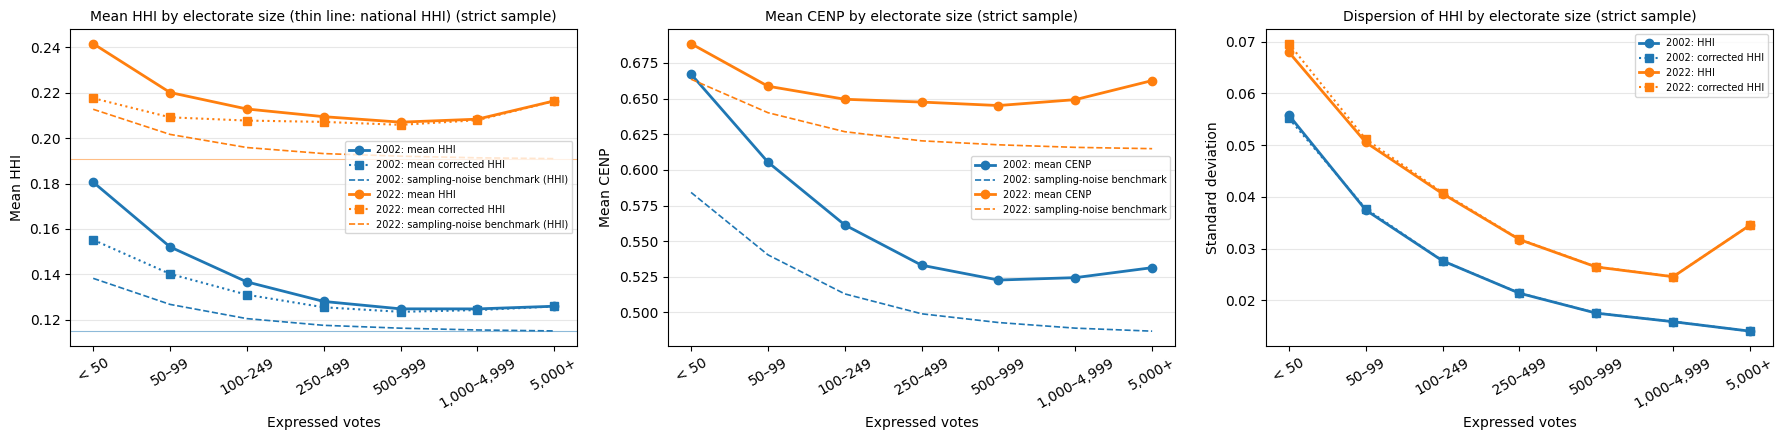

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
for i, year in enumerate(YEARS):
    t = size_table.loc[("strict", year)]
    x = np.arange(len(t))
    axes[0].plot(x, t["HHI_mean"], "o-", color=f"C{i}", lw=2, label=f"{year}: mean HHI")
    axes[0].plot(x, t["HHI_corrected_mean"], "s:", color=f"C{i}", lw=1.5, label=f"{year}: mean corrected HHI")
    axes[0].plot(x, t["HHI_noise_benchmark"], "--", color=f"C{i}", lw=1.2, label=f"{year}: sampling-noise benchmark (HHI)")
    axes[0].axhline(national_hhi[year], color=f"C{i}", lw=0.8, alpha=0.5)
    axes[1].plot(x, t["CENP_mean"], "o-", color=f"C{i}", lw=2, label=f"{year}: mean CENP")
    axes[1].plot(x, t["CENP_noise_benchmark"], "--", color=f"C{i}", lw=1.2, label=f"{year}: sampling-noise benchmark")
    axes[2].plot(x, t["HHI_sd"], "o-", color=f"C{i}", lw=2, label=f"{year}: HHI")
    axes[2].plot(x, t["HHI_corrected_sd"], "s:", color=f"C{i}", lw=1.5, label=f"{year}: corrected HHI")
for ax, title, ylabel in zip(axes, ["Mean HHI by electorate size (thin line: national HHI)",
                                    "Mean CENP by electorate size", "Dispersion of HHI by electorate size"],
                             ["Mean HHI", "Mean CENP", "Standard deviation"]):
    ax.set_xticks(range(len(SIZE_LABELS)))
    ax.set_xticklabels(SIZE_LABELS, rotation=30)
    ax.set_xlabel("Expressed votes")
    ax.set_ylabel(ylabel)
    ax.set_title(title + " (strict sample)", fontsize=10)
    ax.grid(axis="y", alpha=0.3)
    ax.legend(fontsize=7)
show_plot(fig)

In [15]:
# Density slope within each electorate-size bin (removes the size–density confound across bins)
within_rows = []
for y in OUTCOMES:
    for sname, df in SAMPLES.items():
        for year in YEARS:
            d = df[df["year"] == year].assign(size_bin=lambda x: size_bin(x["expressed"]))
            for b, g in d.groupby("size_bin", observed=True):
                if len(g) >= 30:
                    within_rows.append({"outcome": y, "sample": sname, "year": year, "size_bin": b,
                                        **association_stats(g, y)})
within_size = pd.DataFrame(within_rows).set_index(["outcome", "sample", "year", "size_bin"])
display(within_size[["n", "pearson_r", "spearman_rho", "ols_coef", "ols_se_HC1", "ols_p_HC1"]].round(5))

rows = []
for y in OUTCOMES:
    for sname, df in SAMPLES.items():
        for year in YEARS:
            d = df[df["year"] == year].assign(size_bin=lambda x: size_bin(x["expressed"]).astype(str))
            fit = smf.ols(f"{y} ~ log_density + C(size_bin)", data=d).fit(cov_type="HC1")
            rows.append({"outcome": y, "sample": sname, "year": year, "n": int(fit.nobs),
                         "coef_log_density": fit.params["log_density"], "se_HC1": fit.bse["log_density"],
                         "p_HC1": fit.pvalues["log_density"]})
print("outcome ~ log_density + C(size bin):")
display(pd.DataFrame(rows).set_index(["outcome", "sample", "year"]).round(5))

n  pearson_r  spearman_rho  ols_coef  ols_se_HC1  ols_p_HC1
outcome sample year size_bin                                                                    
HHI     strict 2002 < 50          1693   -0.13630      -0.13547  -0.01090     0.00223        0.0
                    50–99         4855   -0.10937      -0.10040  -0.00633     0.00091        0.0
                    100–249      10628   -0.13269      -0.09734  -0.00498     0.00041        0.0
                    250–499       7055   -0.10560      -0.08290  -0.00296     0.00037        0.0
                    500–999       4527   -0.12631      -0.11575  -0.00269     0.00033        0.0
...                                ...        ...           ...       ...         ...        ...
CENP    broad  2022 100–249       9781    0.23376       0.23593   0.02367     0.00100        0.0
                    250–499       7162    0.23498       0.23604   0.01958     0.00094        0.0
                    500–999       5186    0.21478       0.20449   0.01440     0.00093        0.0
                    1,000–4,999   5084    0.22057       0.16668   0.01057     0.00076        0.0
                    5,000+        1030    0.41797       0.39926   0.01833     0.00136        0.0

[84 rows x 6 columns]

outcome ~ log_density + C(size bin):


n  coef_log_density   se_HC1  p_HC1
outcome       sample year                                         
HHI           strict 2002  33581          -0.00340  0.00020    0.0
                     2022  34112           0.00816  0.00025    0.0
              broad  2002  33814          -0.00411  0.00023    0.0
                     2022  34573           0.00830  0.00025    0.0
HHI_corrected strict 2002  33581          -0.00300  0.00020    0.0
                     2022  34112           0.00854  0.00025    0.0
              broad  2002  33813          -0.00357  0.00023    0.0
                     2022  34573           0.00884  0.00025    0.0
CENP          strict 2002  33581          -0.00866  0.00058    0.0
                     2022  34112           0.01694  0.00045    0.0
              broad  2002  33814          -0.00970  0.00059    0.0
                     2022  34573           0.01727  0.00045    0.0

## 7. Density–concentration relationship by electorate threshold

All valid communes, then `expressed ≥ 100`, `≥ 500`, `≥ 1000`; all thresholds shown, none preferred. Same thresholds
for HHI, corrected HHI and CENP.

## 8. Vote-weighted robustness (WLS, weights = expressed)

Robustness only: the unweighted regression describes the *typical commune*, the weighted one the *typical voter*.

In [16]:
threshold_results = pd.concat({y: stats_by_threshold(SAMPLES, y, weighted=True) for y in OUTCOMES}, names=["outcome"])
threshold_summary = threshold_results[["n", "pearson_r", "spearman_rho", "ols_coef", "ols_se", "ols_p",
                                       "ols_se_HC1", "ols_p_HC1", "ols_R2"]]
display(threshold_summary.round(5))
threshold_summary.loc["CENP"].to_csv(AUDIT_DIR / "audit_cenp_density_by_threshold.csv", encoding="utf-8")
threshold_summary.drop(index="CENP").to_csv(AUDIT_DIR / "audit_hhi_density_by_threshold.csv", encoding="utf-8")

n  pearson_r  spearman_rho  ols_coef   ols_se    ols_p  ols_se_HC1  ols_p_HC1   ols_R2
outcome       sample year min_expressed                                                                                            
HHI           strict 2002 0              33581   -0.30596      -0.31050  -0.00744  0.00013  0.00000     0.00014    0.00000  0.09361
                          100            27033   -0.19411      -0.18513  -0.00368  0.00011  0.00000     0.00012    0.00000  0.03768
                          500             9350   -0.03492      -0.02089  -0.00047  0.00014  0.00073     0.00014    0.00109  0.00122
                          1000            4823    0.01175       0.04146   0.00015  0.00018  0.41457     0.00019    0.43716  0.00014
                     2022 0              34112    0.01852       0.07698   0.00055  0.00016  0.00063     0.00018    0.00223  0.00034
                          100            28203    0.12157       0.14897   0.00324  0.00016  0.00000     0.00017    0.00000  0.01478
                          500            11333    0.24274       0.18652   0.00536  0.00020  0.00000     0.00027    0.00000  0.05892
                          1000            6133    0.28658       0.19466   0.00627  0.00027  0.00000     0.00037    0.00000  0.08213
              broad  2002 0              33814   -0.32062      -0.33148  -0.00846  0.00014  0.00000     0.00017    0.00000  0.10280
                          100            26642   -0.20393      -0.19322  -0.00400  0.00012  0.00000     0.00013    0.00000  0.04159
                          500             9065   -0.03483      -0.01814  -0.00047  0.00014  0.00091     0.00015    0.00136  0.00121
                          1000            4668    0.01245       0.04525   0.00016  0.00019  0.39513     0.00020    0.41872  0.00015
                     2022 0              34573    0.02063       0.08242   0.00060  0.00016  0.00012     0.00018    0.00072  0.00043
                          100            28243    0.12830       0.15453   0.00341  0.00016  0.00000     0.00017    0.00000  0.01646
                          500            11300    0.24470       0.18742   0.00542  0.00020  0.00000     0.00027    0.00000  0.05988
                          1000            6114    0.28817       0.19573   0.00635  0.00027  0.00000     0.00038    0.00000  0.08304
HHI_corrected strict 2002 0              33581   -0.20479      -0.17218  -0.00465  0.00012  0.00000     0.00013    0.00000  0.04194
                          100            27033   -0.13256      -0.10645  -0.00247  0.00011  0.00000     0.00012    0.00000  0.01757
                          500             9350   -0.01578       0.00095  -0.00021  0.00014  0.12707     0.00014    0.13983  0.00025
                          1000            4823    0.02145       0.05290   0.00027  0.00018  0.13631     0.00019    0.15586  0.00046
                     2022 0              34112    0.10499       0.16832   0.00307  0.00016  0.00000     0.00017    0.00000  0.01102
                          100            28203    0.16194       0.19304   0.00433  0.00016  0.00000     0.00017    0.00000  0.02623
                          500            11333    0.25267       0.19788   0.00559  0.00020  0.00000     0.00027    0.00000  0.06384
                          1000            6133    0.29122       0.20035   0.00638  0.00027  0.00000     0.00037    0.00000  0.08481
              broad  2002 0              33813   -0.21986      -0.18550  -0.00536  0.00013  0.00000     0.00016    0.00000  0.04834
                          100            26642   -0.14464      -0.11430  -0.00280  0.00012  0.00000     0.00013    0.00000  0.02092
                          500             9065   -0.01556       0.00389  -0.00021  0.00014  0.13839     0.00015    0.15215  0.00024
                          1000            4668    0.02215       0.05672   0.00028  0.00019  0.13023     0.00020    0.15004  0.00049
                     2022 0              34573    0.11611       0.17918   0.00336  0.

In [17]:
wls_comparison = threshold_results[["n", "ols_coef", "ols_se_HC1", "ols_p_HC1", "wls_coef", "wls_se_HC1", "wls_p_HC1", "wls_R2"]].copy()
wls_comparison["wls_minus_ols"] = wls_comparison["wls_coef"] - wls_comparison["ols_coef"]
display(wls_comparison.round(5))

n  ols_coef  ols_se_HC1  ols_p_HC1  wls_coef  wls_se_HC1  wls_p_HC1   wls_R2  wls_minus_ols
outcome       sample year min_expressed                                                                                                 
HHI           strict 2002 0              33581  -0.00744     0.00014    0.00000  -0.00094     0.00031    0.00252  0.01033        0.00651
                          100            27033  -0.00368     0.00012    0.00000  -0.00055     0.00029    0.06351  0.00383        0.00313
                          500             9350  -0.00047     0.00014    0.00109   0.00029     0.00032    0.37040  0.00107        0.00076
                          1000            4823   0.00015     0.00019    0.43716   0.00039     0.00038    0.30322  0.00179        0.00024
                     2022 0              34112   0.00055     0.00018    0.00223   0.00500     0.00039    0.00000  0.09322        0.00445
                          100            28203   0.00324     0.00017    0.00000   0.00528     0.00039    0.00000  0.10354        0.00204
                          500            11333   0.00536     0.00027    0.00000   0.00654     0.00045    0.00000  0.13761        0.00119
                          1000            6133   0.00627     0.00037    0.00000   0.00738     0.00052    0.00000  0.14922        0.00111
              broad  2002 0              33814  -0.00846     0.00017    0.00000  -0.00107     0.00032    0.00081  0.01287        0.00739
                          100            26642  -0.00400     0.00013    0.00000  -0.00061     0.00030    0.04149  0.00471        0.00339
                          500             9065  -0.00047     0.00015    0.00136   0.00029     0.00033    0.37505  0.00108        0.00076
                          1000            4668   0.00016     0.00020    0.41872   0.00039     0.00039    0.31421  0.00176        0.00023
                     2022 0              34573   0.00060     0.00018    0.00072   0.00503     0.00039    0.00000  0.09371        0.00443
                          100            28243   0.00341     0.00017    0.00000   0.00533     0.00039    0.00000  0.10423        0.00192
                          500            11300   0.00542     0.00027    0.00000   0.00659     0.00046    0.00000  0.13747        0.00117
                          1000            6114   0.00635     0.00038    0.00000   0.00742     0.00053    0.00000  0.14856        0.00107
HHI_corrected strict 2002 0              33581  -0.00465     0.00013    0.00000  -0.00029     0.00028    0.29935  0.00102        0.00436
                          100            27033  -0.00247     0.00012    0.00000  -0.00005     0.00027    0.85108  0.00003        0.00242
                          500             9350  -0.00021     0.00014    0.13983   0.00047     0.00031    0.13268  0.00290        0.00068
                          1000            4823   0.00027     0.00019    0.15586   0.00050     0.00038    0.18631  0.00290        0.00023
                     2022 0              34112   0.00307     0.00017    0.00000   0.00549     0.00038    0.00000  0.11162        0.00242
                          100            28203   0.00433     0.00017    0.00000   0.00566     0.00039    0.00000  0.11803        0.00134
                          500            11333   0.00559     0.00027    0.00000   0.00670     0.00045    0.00000  0.14339        0.00111
                          1000            6133   0.00638     0.00037    0.00000   0.00747     0.00052    0.00000  0.15242        0.00108
              broad  2002 0              33813  -0.00536     0.00016    0.00000  -0.00039     0.00028    0.16625  0.00183        0.00497
                          100            26642  -0.00280     0.00013    0.00000  -0.00011     0.00028    0.68921  0.00016        0.00268
                          500             9065  -0.00021     0.00015    0.15215   0.00047     0.00032    0.13708  0.00291        0.00068
                          1000            4668   0.00028     0.00020    

## 9. Density deciles

Deciles of `log_density` (ranks, ties split) within each year and sample restriction. A roughly monotonic profile
means the slope is not driven by a few very dense communes. Compare the **shape** of the two years' profiles.

In [18]:
def decile_table(df):
    d = df.copy()
    d["density_decile"] = d.groupby("year")["log_density"].transform(
        lambda s: pd.qcut(s.rank(method="first"), 10, labels=False) + 1)
    return d.groupby(["year", "density_decile"]).agg(
        n_communes=("commune_code", "size"), density_median=("density", "median"),
        HHI_mean=("HHI", "mean"), HHI_median=("HHI", "median"),
        HHI_corrected_mean=("HHI_corrected", "mean"), HHI_corrected_median=("HHI_corrected", "median"),
        CENP_mean=("CENP", "mean"), CENP_median=("CENP", "median"),
        expressed_median=("expressed", "median"))


DECILE_RESTRICTIONS = {"all valid": 0, "expressed ≥ 500": 500}
decile_tables = {(sname, label): decile_table(df[df["expressed"] >= t])
                 for sname, df in SAMPLES.items() for label, t in DECILE_RESTRICTIONS.items()}
for key, t in decile_tables.items():
    print(f"\n{key[0]} sample, {key[1]}:")
    display(t.round(4))

monotonic = pd.concat({y: pd.DataFrame({key: {year: stats.spearmanr(t.loc[year].index, t.loc[year][f"{y}_mean"]).statistic
                                              for year in YEARS}
                                        for key, t in decile_tables.items()}).T
                       for y in OUTCOMES}, names=["outcome"])
monotonic.index.names = ["outcome", "sample", "restriction"]
print("Spearman(decile, mean outcome):")
display(monotonic.round(3))


strict sample, all valid:


n_communes  density_median  HHI_mean  HHI_median  HHI_corrected_mean  HHI_corrected_median  CENP_mean  CENP_median  expressed_median
year density_decile                                                                                                                                      
2002 1                     3359          7.7454    0.1606      0.1487              0.1470                0.1367     0.6200       0.6182              79.0
     2                     3358         13.1588    0.1481      0.1393              0.1382                0.1301     0.5921       0.5882             107.0
     3                     3358         18.0432    0.1424      0.1361              0.1343                0.1286     0.5783       0.5767             129.0
     4                     3358         24.2563    0.1381      0.1323              0.1315                0.1260     0.5655       0.5626             161.0
     5                     3358         32.3121    0.1350      0.1299              0.1297                0.1249     0.5564       0.5534             204.0
     6                     3358         43.1170    0.1304      0.1267              0.1263                0.1229     0.5418       0.5403             261.0
     7                     3358         58.9562    0.1287      0.1247              0.1254                0.1219     0.5360       0.5321             329.0
     8                     3358         86.0358    0.1262      0.1233              0.1237                0.1211     0.5281       0.5260             449.0
     9                     3358        147.6112    0.1250      0.1221              0.1234                0.1206     0.5233       0.5208             720.0
     10                    3358        476.8716    0.1250      0.1224              0.1244                0.1220     0.5265       0.5221            2180.5
2022 1                     3412          7.3236    0.2132      0.2017              0.2004                0.1898     0.6419       0.6402              79.0
     2                     3411         13.2196    0.2115      0.2016              0.2028                0.1937     0.6432       0.6399             115.0
     3                     3411         19.0883    0.2106      0.2020              0.2039                0.1958     0.6437       0.6408             144.0
     4                     3411         26.2712    0.2147      0.2063              0.2094                0.2016     0.6535       0.6502             187.0
     5                     3411         35.7942    0.2147      0.2086              0.2105                0.2050     0.6550       0.6551             233.0
     6                     3411         48.4127    0.2143      0.2082              0.2112                0.2055     0.6561       0.6543             318.0
     7                     3411         67.3077    0.2124      0.2079              0.2100                0.2059     0.6541       0.6537             415.0
     8                     3411         98.9362    0.2125      0.2082              0.2107                0.2068     0.6557       0.6543             561.0
     9                     3411        169.1638    0.2110      0.2071              0.2099                0.2062     0.6542       0.6520             906.0
     10                    3412        529.3581    0.2146      0.2079              0.2141                0.2075     0.6602       0.6536            2649.5


strict sample, expressed ≥ 500:


n_communes  density_median  HHI_mean  HHI_median  HHI_corrected_mean  HHI_corrected_median  CENP_mean  CENP_median  expressed_median
year density_decile                                                                                                                                      
2002 1                      935         29.1562    0.1298      0.1261              0.1285                0.1249     0.5412       0.5382             642.0
     2                      935         47.8673    0.1263      0.1237              0.1251                0.1227     0.5289       0.5279             720.0
     3                      935         68.0700    0.1242      0.1224              0.1231                0.1211     0.5212       0.5220             787.0
     4                      935         90.5531    0.1232      0.1214              0.1222                0.1204     0.5180       0.5175             842.0
     5                      935        119.1045    0.1226      0.1194              0.1216                0.1183     0.5141       0.5082             917.0
     6                      935        158.4295    0.1237      0.1214              0.1228                0.1206     0.5195       0.5177             995.0
     7                      935        213.5772    0.1239      0.1207              0.1231                0.1197     0.5201       0.5142            1143.0
     8                      935        313.1679    0.1235      0.1208              0.1228                0.1200     0.5200       0.5147            1485.0
     9                      935        563.0970    0.1247      0.1223              0.1242                0.1218     0.5260       0.5217            2353.0
     10                     935       1701.4820    0.1262      0.1235              0.1260                0.1233     0.5329       0.5267            5535.0
2022 1                     1134         29.4516    0.1975      0.1941              0.1964                0.1928     0.6238       0.6227             680.0
     2                     1133         50.1487    0.2032      0.2005              0.2022                0.1995     0.6378       0.6376             739.0
     3                     1133         68.9384    0.2057      0.2038              0.2048                0.2029     0.6429       0.6448             808.0
     4                     1133         90.7522    0.2083      0.2057              0.2074                0.2049     0.6490       0.6490             832.0
     5                     1134        118.3383    0.2078      0.2046              0.2069                0.2039     0.6479       0.6466             935.5
     6                     1133        154.9387    0.2094      0.2060              0.2086                0.2054     0.6517       0.6496            1090.0
     7                     1133        209.3098    0.2096      0.2066              0.2089                0.2059     0.6521       0.6509            1213.0
     8                     1133        297.7027    0.2101      0.2065              0.2095                0.2060     0.6533       0.6507            1563.0
     9                     1133        523.1263    0.2109      0.2062              0.2105                0.2058     0.6546       0.6500            2443.0
     10                    1134       1546.5973    0.2226      0.2122              0.2224                0.2120     0.6728       0.6625            5786.5


broad sample, all valid:


n_communes  density_median  HHI_mean  HHI_median  HHI_corrected_mean  HHI_corrected_median  CENP_mean  CENP_median  expressed_median
year density_decile                                                                                                                                      
2002 1                     3382          6.6568    0.1671      0.1527              0.1515                0.1381     0.6320       0.6299              71.0
     2                     3381         12.1856    0.1514      0.1416              0.1408                0.1322     0.5991       0.5957             101.0
     3                     3381         17.1081    0.1432      0.1362              0.1346                0.1284     0.5799       0.5774             123.0
     4                     3382         23.0267    0.1395      0.1336              0.1326                0.1271     0.5694       0.5675             153.0
     5                     3381         30.9442    0.1360      0.1305              0.1304                0.1253     0.5595       0.5560             195.0
     6                     3381         41.6935    0.1304      0.1266              0.1261                0.1227     0.5416       0.5400             248.0
     7                     3382         57.2277    0.1293      0.1252              0.1258                0.1222     0.5376       0.5343             317.0
     8                     3381         83.8995    0.1265      0.1234              0.1239                0.1212     0.5288       0.5264             433.0
     9                     3381        144.4019    0.1251      0.1222              0.1235                0.1206     0.5238       0.5213             694.0
     10                    3382        467.8141    0.1250      0.1224              0.1244                0.1219     0.5264       0.5221            2137.0
2022 1                     3458          6.6087    0.2129      0.2005              0.1986                0.1877     0.6405       0.6375              73.0
     2                     3457         12.5395    0.2111      0.2016              0.2020                0.1933     0.6421       0.6399             110.0
     3                     3457         18.3468    0.2108      0.2018              0.2039                0.1954     0.6438       0.6404             138.0
     4                     3457         25.5512    0.2142      0.2060              0.2087                0.2008     0.6522       0.6496             181.0
     5                     3458         34.9472    0.2148      0.2084              0.2105                0.2048     0.6550       0.6548             228.0
     6                     3457         47.4299    0.2145      0.2084              0.2112                0.2058     0.6563       0.6547             308.0
     7                     3457         66.1413    0.2126      0.2080              0.2101                0.2059     0.6542       0.6538             410.0
     8                     3457         97.3502    0.2125      0.2083              0.2107                0.2069     0.6557       0.6544             557.0
     9                     3457        166.4927    0.2110      0.2071              0.2098                0.2060     0.6541       0.6519             888.0
     10                    3458        519.8020    0.2147      0.2079              0.2143                0.2075     0.6604       0.6537            2606.0


broad sample, expressed ≥ 500:


n_communes  density_median  HHI_mean  HHI_median  HHI_corrected_mean  HHI_corrected_median  CENP_mean  CENP_median  expressed_median
year density_decile                                                                                                                                      
2002 1                      907         29.4986    0.1300      0.1263              0.1287                0.1251     0.5417       0.5390             644.0
     2                      906         48.6693    0.1260      0.1236              0.1248                0.1225     0.5273       0.5271             715.5
     3                      907         69.6039    0.1240      0.1222              0.1229                0.1208     0.5206       0.5210             775.0
     4                      906         92.4013    0.1234      0.1214              0.1223                0.1204     0.5184       0.5175             845.5
     5                      907        121.3247    0.1227      0.1193              0.1217                0.1183     0.5146       0.5080             908.0
     6                      906        161.1846    0.1235      0.1214              0.1226                0.1206     0.5190       0.5176            1008.0
     7                      906        218.6673    0.1240      0.1207              0.1232                0.1198     0.5203       0.5143            1143.0
     8                      907        321.8463    0.1236      0.1210              0.1229                0.1203     0.5205       0.5158            1504.0
     9                      906        576.8538    0.1246      0.1221              0.1241                0.1216     0.5254       0.5208            2411.0
     10                     907       1731.1144    0.1263      0.1236              0.1261                0.1235     0.5333       0.5273            5601.0
2022 1                     1130         29.4418    0.1975      0.1938              0.1963                0.1925     0.6237       0.6219             680.0
     2                     1130         50.1936    0.2032      0.2005              0.2022                0.1995     0.6379       0.6376             737.5
     3                     1130         69.0884    0.2058      0.2037              0.2048                0.2028     0.6430       0.6447             807.5
     4                     1130         90.9331    0.2084      0.2060              0.2075                0.2052     0.6491       0.6497             832.0
     5                     1130        118.4186    0.2078      0.2046              0.2070                0.2039     0.6480       0.6466             938.5
     6                     1130        155.1778    0.2093      0.2060              0.2085                0.2052     0.6516       0.6496            1085.5
     7                     1130        209.7542    0.2096      0.2067              0.2089                0.2060     0.6522       0.6510            1210.5
     8                     1130        298.2743    0.2102      0.2066              0.2096                0.2061     0.6534       0.6509            1578.5
     9                     1130        524.8698    0.2109      0.2062              0.2105                0.2058     0.6545       0.6500            2460.0
     10                    1130       1559.7371    0.2230      0.2123              0.2228                0.2121     0.6733       0.6628            5802.0

Spearman(decile, mean outcome):


2002   2022
outcome       sample restriction                  
HHI           strict all valid       -1.000  0.079
                     expressed ≥ 500 -0.212  0.988
              broad  all valid       -1.000  0.164
                     expressed ≥ 500 -0.042  0.988
HHI_corrected strict all valid       -0.964  0.818
                     expressed ≥ 500 -0.042  0.988
              broad  all valid       -0.964  0.818
                     expressed ≥ 500  0.018  0.988
CENP          strict all valid       -0.988  0.842
                     expressed ≥ 500 -0.091  0.988
              broad  all valid       -0.988  0.818
                     expressed ≥ 500 -0.079  0.988

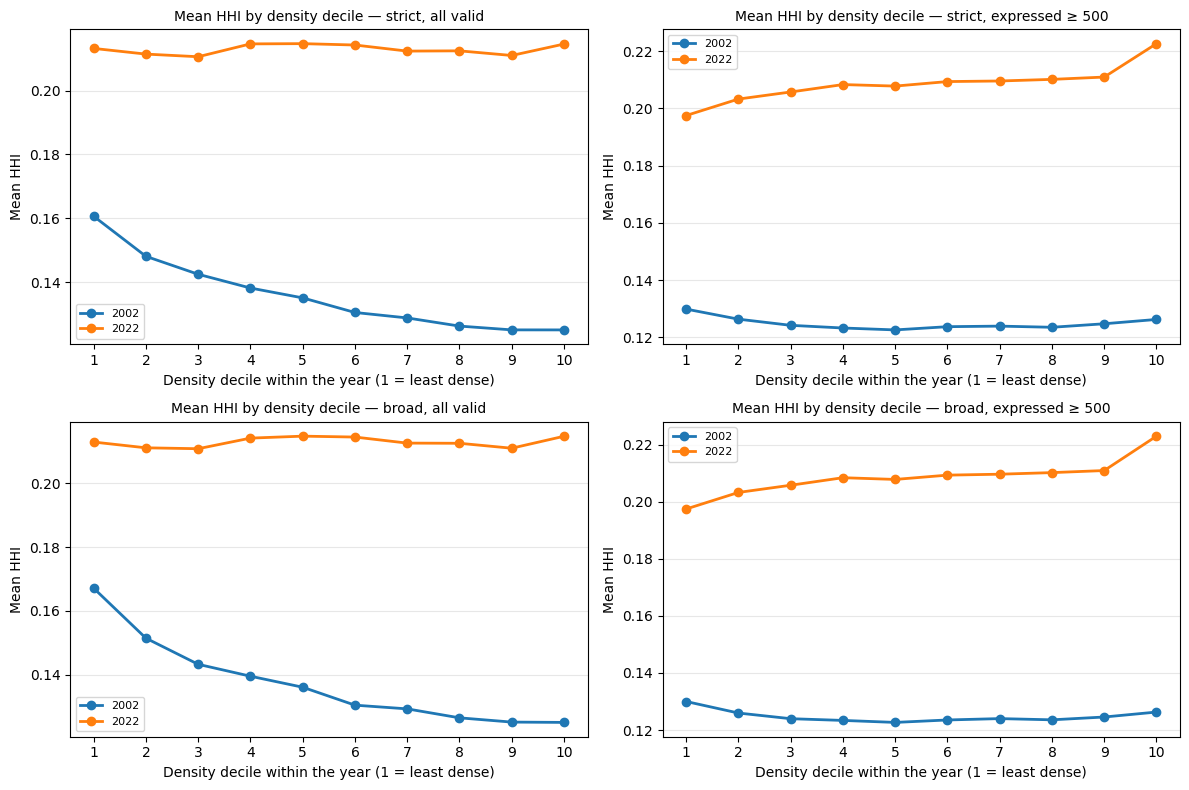

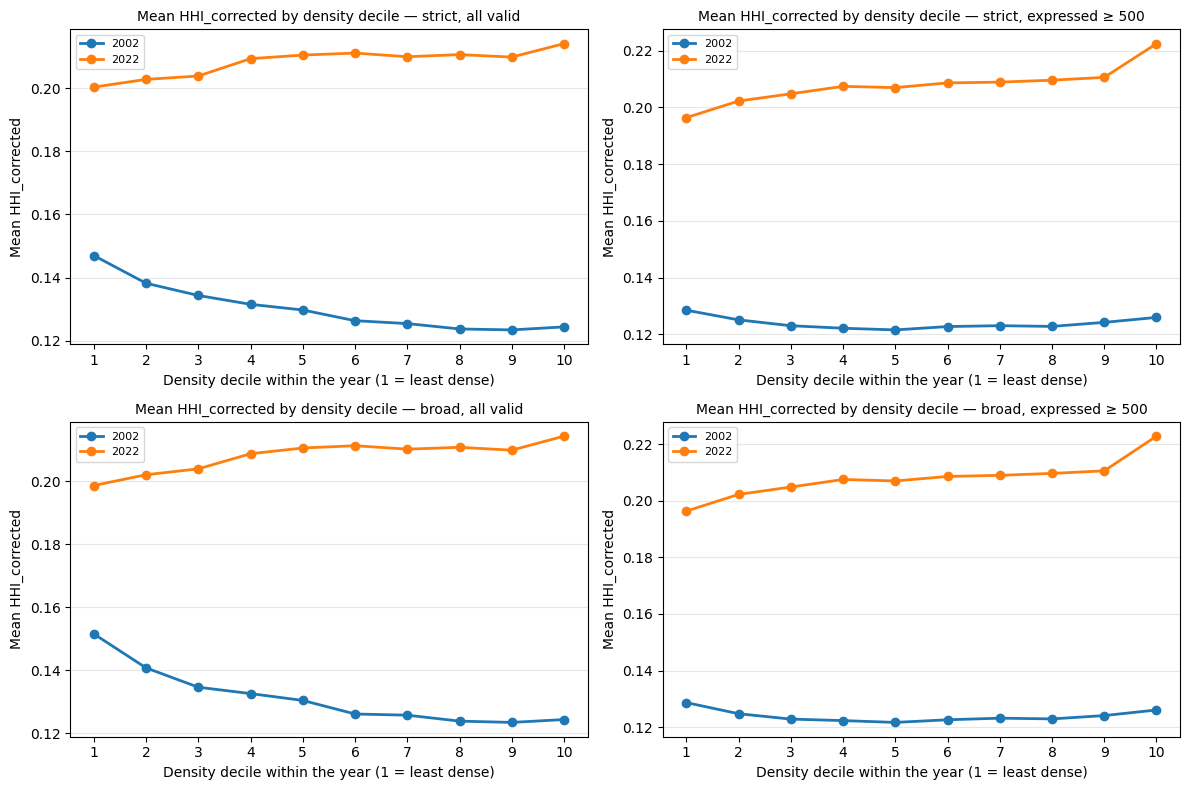

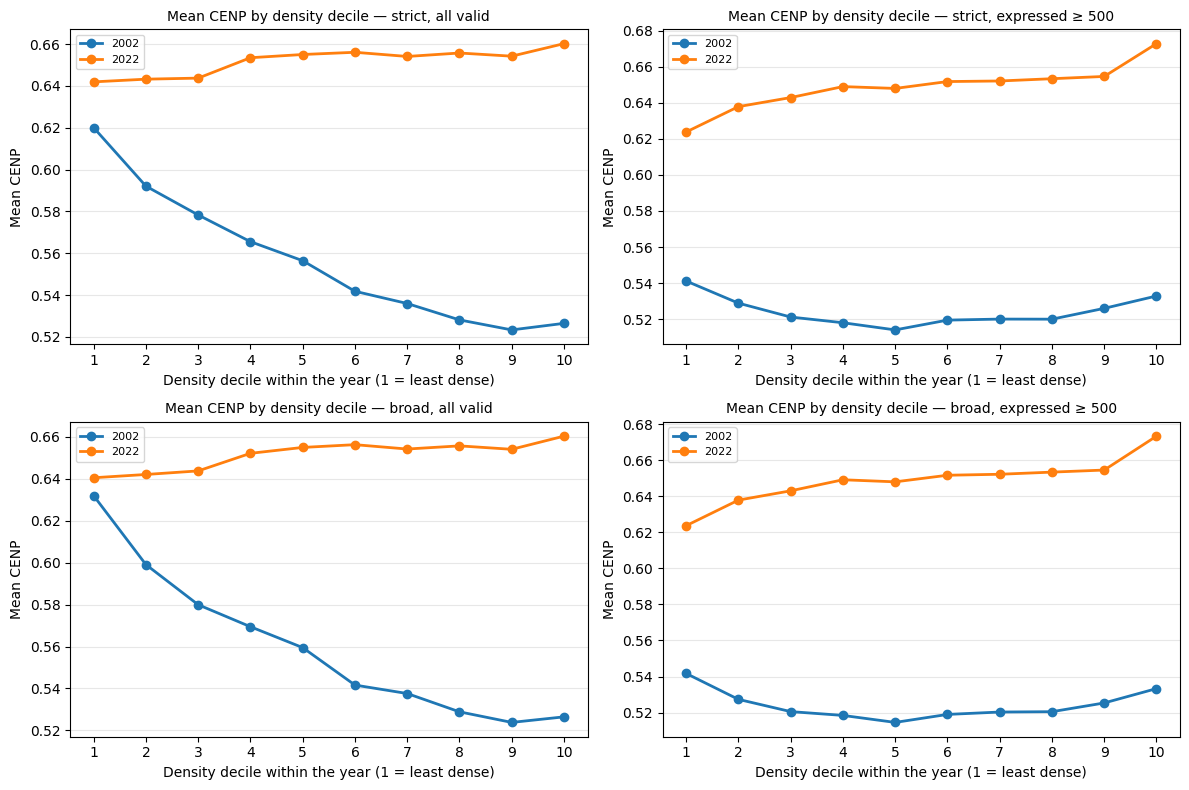

In [19]:
for y in OUTCOMES:
    fig, axes = plt.subplots(len(SAMPLES), len(DECILE_RESTRICTIONS), figsize=(12, 4 * len(SAMPLES)), squeeze=False)
    for i, sname in enumerate(SAMPLES):
        for j, label in enumerate(DECILE_RESTRICTIONS):
            ax, t = axes[i, j], decile_tables[(sname, label)]
            for k, year in enumerate(YEARS):
                ax.plot(t.loc[year].index, t.loc[year][f"{y}_mean"], "o-", color=f"C{k}", lw=2, label=str(year))
            ax.set_xticks(range(1, 11))
            ax.set_xlabel("Density decile within the year (1 = least dense)")
            ax.set_ylabel(f"Mean {y}")
            ax.set_title(f"Mean {y} by density decile — {sname}, {label}", fontsize=10)
            ax.grid(axis="y", alpha=0.3)
            ax.legend(fontsize=8)
    show_plot(fig)

## 10. Within départements: département fixed effects

$$y_i = \beta\,\log\text{density}_i + \alpha_{d(i)} + \varepsilon_i, \qquad y \in \{\text{HHI}, \text{HHI}_\text{corrected}, \text{CENP}\}$$

The département dummies absorb everything shared by communes of the same département (regional traditions,
candidates' home bases, the département's average urbanisation): $\beta$ answers *within the same département, are
denser communes more concentrated?* Communes with `expressed ≥ 500` and `≥ 1000`; HC1 and département-clustered SE.

In [20]:
FE_THRESHOLDS = [500, 1000]
fe_table = pd.DataFrame([{"outcome": y, "sample": sname, "year": year, "min_expressed": t,
                          **fe_stats(df[(df["year"] == year) & (df["expressed"] >= t)], y)}
                         for y in OUTCOMES for sname, df in SAMPLES.items() for year in YEARS for t in FE_THRESHOLDS]
                        ).set_index(["outcome", "sample", "year", "min_expressed"])
display(fe_table.round(5))

n  n_departements     coef   se_HC1    p_HC1  se_cluster_dep  p_cluster_dep       R2  coef_without_FE
outcome       sample year min_expressed                                                                                                           
HHI           strict 2002 500             9350              96 -0.00040  0.00015  0.00592         0.00036        0.26993  0.24567         -0.00047
                          1000            4823              96  0.00046  0.00020  0.02372         0.00036        0.20743  0.27949          0.00015
                     2022 500            11333              96  0.00187  0.00020  0.00000         0.00060        0.00169  0.46489          0.00536
                          1000            6133              96  0.00230  0.00028  0.00000         0.00066        0.00047  0.47245          0.00627
              broad  2002 500             9065              96 -0.00035  0.00015  0.01662         0.00036        0.32262  0.24663         -0.00047
                          1000            4668              96  0.00057  0.00021  0.00588         0.00036        0.11417  0.28119          0.00016
                     2022 500            11300              96  0.00193  0.00021  0.00000         0.00059        0.00114  0.46452          0.00542
                          1000            6114              96  0.00235  0.00028  0.00000         0.00066        0.00034  0.47168          0.00635
HHI_corrected strict 2002 500             9350              96 -0.00010  0.00015  0.50633         0.00037        0.79101  0.24435         -0.00021
                          1000            4823              96  0.00061  0.00020  0.00263         0.00036        0.09440  0.27947          0.00027
                     2022 500            11333              96  0.00214  0.00021  0.00000         0.00060        0.00035  0.46661          0.00559
                          1000            6133              96  0.00243  0.00028  0.00000         0.00066        0.00022  0.47363          0.00638
              broad  2002 500             9065              96 -0.00005  0.00015  0.74501         0.00036        0.89365  0.24538         -0.00021
                          1000            4668              96  0.00072  0.00021  0.00047         0.00036        0.04556  0.28121          0.00028
                     2022 500            11300              96  0.00220  0.00021  0.00000         0.00060        0.00022  0.46626          0.00565
                          1000            6114              96  0.00248  0.00028  0.00000         0.00066        0.00016  0.47288          0.00646
CENP          strict 2002 500             9350              96 -0.00053  0.00057  0.34857         0.00140        0.70507  0.24034         -0.00062
                          1000            4823              96  0.00291  0.00077  0.00016         0.00135        0.03141  0.28112          0.00164
                     2022 500            11333              96  0.00415  0.00037  0.00000         0.00100        0.00004  0.50226          0.01030
                          1000            6133              96  0.00450  0.00049  0.00000         0.00106        0.00002  0.51354          0.01099
              broad  2002 500             9065              96 -0.00031  0.00057  0.58170         0.00138        0.81974  0.24090         -0.00057
                          1000            4668              96  0.00343  0.00079  0.00001         0.00134        0.01029  0.28323          0.00176
                     2022 500            11300              96  0.00425  0.00037  0.00000         0.00100        0.00002  0.50231          0.01038
                          1000            6114              96  0.00457  0.00049  0.00000         0.00107        0.00002  0.51359          0.01109

## 11. Pooled comparison of the 2002 and 2022 slopes

$\beta_3$ (`log_density:C(year)[T.2022]`) = 2022 slope − 2002 slope, on stacked cross-sections; HC1 and
département-clustered SE. HHI and corrected HHI are on the same scale in both elections; CENP depends on the number
of candidates (16 vs 12) and is kept for continuity.

In [21]:
POOLED_THRESHOLDS = [0, 500, 1000]
TERM = "log_density:C(year)[T.2022]"
pooled_rows = []
for y in OUTCOMES:
    for sname, df in SAMPLES.items():
        for t in POOLED_THRESHOLDS:
            d = df.loc[df["expressed"] >= t, [y, "log_density", "year", "department_code"]].dropna()
            hc1 = smf.ols(f"{y} ~ log_density * C(year)", data=d).fit(cov_type="HC1")
            cl = smf.ols(f"{y} ~ log_density * C(year)", data=d).fit(cov_type="cluster",
                                                                    cov_kwds={"groups": d["department_code"]})
            pooled_rows.append({"outcome": y, "sample": sname, "min_expressed": t, "n": int(hc1.nobs),
                                "slope_2002": hc1.params["log_density"],
                                "slope_2022": hc1.params["log_density"] + hc1.params[TERM],
                                "interaction_2022": hc1.params[TERM], "se_HC1": hc1.bse[TERM], "p_HC1": hc1.pvalues[TERM],
                                "se_cluster_dep": cl.bse[TERM], "p_cluster_dep": cl.pvalues[TERM], "R2": hc1.rsquared})
pooled_table = pd.DataFrame(pooled_rows).set_index(["outcome", "sample", "min_expressed"])
display(pooled_table.round(5))
print("Density slope by year (separate cross-sections, OLS, HC1):")
display(threshold_results[["n", "ols_coef", "ols_se_HC1", "ols_p_HC1"]].unstack("year").round(5))

n  slope_2002  slope_2022  interaction_2022   se_HC1  p_HC1  se_cluster_dep  p_cluster_dep       R2
outcome       sample min_expressed                                                                                                         
HHI           strict 0              67693    -0.00744     0.00055           0.00799  0.00023    0.0         0.00102        0.00000  0.56221
                     500            20683    -0.00047     0.00536           0.00582  0.00030    0.0         0.00114        0.00000  0.78262
                     1000           10956     0.00015     0.00627           0.00612  0.00042    0.0         0.00142        0.00002  0.79278
              broad  0              68387    -0.00846     0.00060           0.00906  0.00025    0.0         0.00110        0.00000  0.53276
                     500            20365    -0.00047     0.00542           0.00588  0.00031    0.0         0.00113        0.00000  0.78052
                     1000           10782     0.00016     0.00635           0.00619  0.00042    0.0         0.00141        0.00001  0.78981
HHI_corrected strict 0              67693    -0.00465     0.00307           0.00772  0.00022    0.0         0.00104        0.00000  0.57608
                     500            20683    -0.00021     0.00559           0.00580  0.00030    0.0         0.00114        0.00000  0.78313
                     1000           10956     0.00027     0.00638           0.00611  0.00042    0.0         0.00142        0.00002  0.79306
              broad  0              68386    -0.00536     0.00336           0.00872  0.00023    0.0         0.00111        0.00000  0.54904
                     500            20365    -0.00021     0.00565           0.00586  0.00031    0.0         0.00113        0.00000  0.78104
                     1000           10782     0.00028     0.00646           0.00618  0.00042    0.0         0.00141        0.00001  0.79009
CENP          strict 0              67693    -0.02057     0.00438           0.02495  0.00048    0.0         0.00213        0.00000  0.29421
                     500            20683    -0.00062     0.01030           0.01092  0.00068    0.0         0.00217        0.00000  0.54889
                     1000           10956     0.00164     0.01099           0.00935  0.00090    0.0         0.00255        0.00025  0.58938
              broad  0              68387    -0.02231     0.00459           0.02691  0.00048    0.0         0.00225        0.00000  0.28274
                     500            20365    -0.00057     0.01038           0.01096  0.00069    0.0         0.00213        0.00000  0.54915
                     1000           10782     0.00176     0.01109           0.00933  0.00092    0.0         0.00253        0.00023  0.58905

Density slope by year (separate cross-sections, OLS, HC1):


n        ols_coef          ols_se_HC1          ols_p_HC1         
year                                 2002   2022     2002     2022       2002     2022      2002     2022
outcome       sample min_expressed                                                                       
HHI           broad  0              33814  34573 -0.00846  0.00060    0.00017  0.00018   0.00000  0.00072
                     100            26642  28243 -0.00400  0.00341    0.00013  0.00017   0.00000  0.00000
                     500             9065  11300 -0.00047  0.00542    0.00015  0.00027   0.00136  0.00000
                     1000            4668   6114  0.00016  0.00635    0.00020  0.00038   0.41872  0.00000
              strict 0              33581  34112 -0.00744  0.00055    0.00014  0.00018   0.00000  0.00223
                     100            27033  28203 -0.00368  0.00324    0.00012  0.00017   0.00000  0.00000
                     500             9350  11333 -0.00047  0.00536    0.00014  0.00027   0.00109  0.00000
                     1000            4823   6133  0.00015  0.00627    0.00019  0.00037   0.43716  0.00000
HHI_corrected broad  0              33813  34573 -0.00536  0.00336    0.00016  0.00017   0.00000  0.00000
                     100            26642  28243 -0.00280  0.00450    0.00013  0.00017   0.00000  0.00000
                     500             9065  11300 -0.00021  0.00565    0.00015  0.00027   0.15215  0.00000
                     1000            4668   6114  0.00028  0.00646    0.00020  0.00038   0.15004  0.00000
              strict 0              33581  34112 -0.00465  0.00307    0.00013  0.00017   0.00000  0.00000
                     100            27033  28203 -0.00247  0.00433    0.00012  0.00017   0.00000  0.00000
                     500             9350  11333 -0.00021  0.00559    0.00014  0.00027   0.13983  0.00000
                     1000            4823   6133  0.00027  0.00638    0.00019  0.00037   0.15586  0.00000
CENP          broad  0              33814  34573 -0.02231  0.00459    0.00038  0.00029   0.00000  0.00000
                     100            26642  28243 -0.01153  0.00871    0.00039  0.00030   0.00000  0.00000
                     500             9065  11300 -0.00057  0.01038    0.00053  0.00043   0.28478  0.00000
                     1000            4668   6114  0.00176  0.01109    0.00072  0.00057   0.01405  0.00000
              strict 0              33581  34112 -0.02057  0.00438    0.00038  0.00029   0.00000  0.00000
                     100            27033  28203 -0.01081  0.00836    0.00038  0.00030   0.00000  0.00000
                     500             9350  11333 -0.00062  0.01030    0.00053  0.00043   0.23880  0.00000
                     1000            4823   6133  0.00164  0.01099    0.00070  0.00057   0.01930  0.00000

## Audit summary

Computed from the cells above — nothing is hard-coded. With tens of thousands of communes, tiny slopes are
"significant", so the **magnitude** columns of the scorecards (change in the outcome from the 25th to the 75th
percentile of log density, in outcome units and in standard deviations) matter as much as the p-values. One scorecard
per outcome: HHI (main), corrected HHI (small-electorate check), CENP (continuity).

In [22]:
print("1. Scrape failures")
display(scrape_summary[["expected_communes", "scraped_communes", "failed_communes", "pct_recovered",
                        "territories_without_commune_pages", "expected_from"]])
print(f"   Communes scraped but with 0 expressed votes: {zero_expressed.groupby('year').size().to_dict()}")

print("\n2. Sample sizes (metropolitan)")
sizes = sample_counts[["metropolitan_election_obs", "valid_density", "main_sample"]].rename(columns={"main_sample": "strict"})
sizes["broad"] = broad.groupby("year").size()
sizes["all_matched"] = all_matched.groupby("year").size()
for col in ["strict", "broad"]:
    sizes[f"pct_{col}"] = (100 * sizes[col] / sizes["metropolitan_election_obs"]).round(2)
display(sizes)

print("\n3. Exclusions from the strict sample by primary reason (metropolitan observations)")
display(pd.concat({"n": exclusion_counts.drop(index=["overseas", RETAINED]),
                   "% of metropolitan": exclusion_pct_metro.drop(index=RETAINED)}, axis=1))

print("\n4. Population used for the 2002 density:", POP_2002_FOR_DENSITY)
display(pop_results.xs(2002, level="year")[["n", "ols_coef", "ols_se_HC1", "pearson_r"]].unstack("min_expressed").round(4))

print("\n5. Density associations (HHI, corrected HHI, CENP) by threshold and year")
display(threshold_results[["n", "pearson_r", "spearman_rho", "ols_coef", "ols_se_HC1", "ols_p_HC1"]].unstack("year").round(4))

print("\n6. Within-département (FE) slopes")
display(fe_table[["n", "coef", "se_HC1", "p_HC1", "p_cluster_dep", "coef_without_FE"]].unstack("year").round(4))

print("\n7. Pooled year × density interaction")
display(pooled_table[["n", "slope_2002", "slope_2022", "interaction_2022", "se_cluster_dep", "p_cluster_dep"]].round(4))

1. Scrape failures


,expected_communes,scraped_communes,failed_communes,pct_recovered,territories_without_commune_pages,expected_from
year,,,,,,
2002,36674,36674,0,100.0,4,parsed + recorded commune failures
2022,35034,35034,0,100.0,2,parsed + recorded commune failures


   Communes scraped but with 0 expressed votes: {2022: 14}

2. Sample sizes (metropolitan)


,metropolitan_election_obs,valid_density,strict,broad,all_matched,pct_strict,pct_broad
year,,,,,,,
2002,36559,34717,33581,33814,34717,91.85,92.49
2022,34820,34728,34112,34573,34715,97.97,99.29



3. Exclusions from the strict sample by primary reason (metropolitan observations)


...

n        pearson_r         spearman_rho         ols_coef         ols_se_HC1         ols_p_HC1        
year                                 2002   2022      2002    2022         2002    2022     2002    2022       2002    2022      2002    2022
outcome       sample min_expressed                                                                                                           
HHI           broad  0              33814  34573   -0.3206  0.0206      -0.3315  0.0824  -0.0085  0.0006     0.0002  0.0002    0.0000  0.0007
                     100            26642  28243   -0.2039  0.1283      -0.1932  0.1545  -0.0040  0.0034     0.0001  0.0002    0.0000  0.0000
                     500             9065  11300   -0.0348  0.2447      -0.0181  0.1874  -0.0005  0.0054     0.0001  0.0003    0.0014  0.0000
                     1000            4668   6114    0.0124  0.2882       0.0453  0.1957   0.0002  0.0063     0.0002  0.0004    0.4187  0.0000
              strict 0              33581  34112   -0.3060  0.0185      -0.3105  0.0770  -0.0074  0.0005     0.0001  0.0002    0.0000  0.0022
                     100            27033  28203   -0.1941  0.1216      -0.1851  0.1490  -0.0037  0.0032     0.0001  0.0002    0.0000  0.0000
                     500             9350  11333   -0.0349  0.2427      -0.0209  0.1865  -0.0005  0.0054     0.0001  0.0003    0.0011  0.0000
                     1000            4823   6133    0.0118  0.2866       0.0415  0.1947   0.0001  0.0063     0.0002  0.0004    0.4372  0.0000
HHI_corrected broad  0              33813  34573   -0.2199  0.1161      -0.1855  0.1792  -0.0054  0.0034     0.0002  0.0002    0.0000  0.0000
                     100            26642  28243   -0.1446  0.1689      -0.1143  0.1987  -0.0028  0.0045     0.0001  0.0002    0.0000  0.0000
                     500             9065  11300   -0.0156  0.2546       0.0039  0.1988  -0.0002  0.0056     0.0001  0.0003    0.1522  0.0000
                     1000            4668   6114    0.0222  0.2928       0.0567  0.2014   0.0003  0.0065     0.0002  0.0004    0.1500  0.0000
              strict 0              33581  34112   -0.2048  0.1050      -0.1722  0.1683  -0.0046  0.0031     0.0001  0.0002    0.0000  0.0000
                     100            27033  28203   -0.1326  0.1619      -0.1065  0.1930  -0.0025  0.0043     0.0001  0.0002    0.0000  0.0000
                     500             9350  11333   -0.0158  0.2527       0.0009  0.1979  -0.0002  0.0056     0.0001  0.0003    0.1398  0.0000
                     1000            4823   6133    0.0215  0.2912       0.0529  0.2004   0.0003  0.0064     0.0002  0.0004    0.1559  0.0000
CENP          broad  0              33814  34573   -0.3126  0.0867      -0.3315  0.0824  -0.0223  0.0046     0.0004  0.0003    0.0000  0.0000
                     100            26642  28243   -0.1766  0.1699      -0.1932  0.1545  -0.0115  0.0087     0.0004  0.0003    0.0000  0.0000
                     500             9065  11300   -0.0110  0.2451      -0.0181  0.1874  -0.0006  0.0104     0.0005  0.0004    0.2848  0.0000
                     1000            4668   6114    0.0359  0.2785       0.0453  0.1957   0.0018  0.0111     0.0007  0.0006    0.0141  0.0000
              strict 0              33581  34112   -0.2874  0.0818      -0.3105  0.0770  -0.0206  0.0044     0.0004  0.0003    0.0000  0.0000
                     100            27033  28203   -0.1653  0.1625      -0.1851  0.1490  -0.0108  0.0084     0.0004  0.0003    0.0000  0.0000
                     500             9350  11333   -0.0119  0.2434      -0.0209  0.1865  -0.0006  0.0103     0.0005  0.0004    0.2388  0.0000
                     1000            4823   6133    0.0337  0.2769       0.0415  0.1947   0.0016  0.0110     0.0007  0.0006    0.0193  0.0000


6. Within-département (FE) slopes


n           coef          se_HC1           p_HC1      p_cluster_dep         coef_without_FE        
year                                2002   2022    2002    2022    2002    2022    2002 2022          2002    2022            2002    2022
outcome       sample min_expressed                                                                                                        
CENP          broad  500            9065  11300 -0.0003  0.0043  0.0006  0.0004  0.5817  0.0        0.8197  0.0000         -0.0006  0.0104
                     1000           4668   6114  0.0034  0.0046  0.0008  0.0005  0.0000  0.0        0.0103  0.0000          0.0018  0.0111
              strict 500            9350  11333 -0.0005  0.0041  0.0006  0.0004  0.3486  0.0        0.7051  0.0000         -0.0006  0.0103
                     1000           4823   6133  0.0029  0.0045  0.0008  0.0005  0.0002  0.0        0.0314  0.0000          0.0016  0.0110
HHI           broad  500            9065  11300 -0.0004  0.0019  0.0001  0.0002  0.0166  0.0        0.3226  0.0011         -0.0005  0.0054
                     1000           4668   6114  0.0006  0.0024  0.0002  0.0003  0.0059  0.0        0.1142  0.0003          0.0002  0.0063
              strict 500            9350  11333 -0.0004  0.0019  0.0001  0.0002  0.0059  0.0        0.2699  0.0017         -0.0005  0.0054
                     1000           4823   6133  0.0005  0.0023  0.0002  0.0003  0.0237  0.0        0.2074  0.0005          0.0001  0.0063
HHI_corrected broad  500            9065  11300 -0.0000  0.0022  0.0001  0.0002  0.7450  0.0        0.8937  0.0002         -0.0002  0.0056
                     1000           4668   6114  0.0007  0.0025  0.0002  0.0003  0.0005  0.0        0.0456  0.0002          0.0003  0.0065
              strict 500            9350  11333 -0.0001  0.0021  0.0001  0.0002  0.5063  0.0        0.7910  0.0003         -0.0002  0.0056
                     1000           4823   6133  0.0006  0.0024  0.0002  0.0003  0.0026  0.0        0.0944  0.0002          0.0003  0.0064


7. Pooled year × density interaction


n  slope_2002  slope_2022  interaction_2022  se_cluster_dep  p_cluster_dep
outcome       sample min_expressed                                                                                
HHI           strict 0              67693     -0.0074      0.0005            0.0080          0.0010         0.0000
                     500            20683     -0.0005      0.0054            0.0058          0.0011         0.0000
                     1000           10956      0.0001      0.0063            0.0061          0.0014         0.0000
              broad  0              68387     -0.0085      0.0006            0.0091          0.0011         0.0000
                     500            20365     -0.0005      0.0054            0.0059          0.0011         0.0000
                     1000           10782      0.0002      0.0063            0.0062          0.0014         0.0000
HHI_corrected strict 0              67693     -0.0046      0.0031            0.0077          0.0010         0.0000
                     500            20683     -0.0002      0.0056            0.0058          0.0011         0.0000
                     1000           10956      0.0003      0.0064            0.0061          0.0014         0.0000
              broad  0              68386     -0.0054      0.0034            0.0087          0.0011         0.0000
                     500            20365     -0.0002      0.0056            0.0059          0.0011         0.0000
                     1000           10782      0.0003      0.0065            0.0062          0.0014         0.0000
CENP          strict 0              67693     -0.0206      0.0044            0.0250          0.0021         0.0000
                     500            20683     -0.0006      0.0103            0.0109          0.0022         0.0000
                     1000           10956      0.0016      0.0110            0.0093          0.0025         0.0002
              broad  0              68387     -0.0223      0.0046            0.0269          0.0022         0.0000
                     500            20365     -0.0006      0.0104            0.0110          0.0021         0.0000
                     1000           10782      0.0018      0.0111            0.0093          0.0025         0.0002

In [23]:
# Robustness scorecards: every pre-specified specification, same yes/no questions, one scorecard per outcome
iqr = {year: strict.loc[strict["year"] == year, "log_density"].quantile(0.75)
             - strict.loc[strict["year"] == year, "log_density"].quantile(0.25) for year in YEARS}
FLAGS = ["2022 > 0 (p<0.05)", "2002 > 0 (p<0.05)", "2002 < 0 (p<0.05)", "2022 slope > 2002 slope"]


def scorecard(y):
    sd = {year: strict.loc[strict["year"] == year, y].std() for year in YEARS}
    score = []
    for (sname, t), g in threshold_results.loc[y].reset_index().groupby(["sample", "min_expressed"]):
        r = g.set_index("year")
        for spec, c, p in [("OLS", "ols_coef", "ols_p_HC1"), ("WLS (robustness)", "wls_coef", "wls_p_HC1")]:
            score.append({"specification": spec, "sample": sname, "min_expressed": t,
                          "slope_2002": r.at[2002, c], "p_2002": r.at[2002, p], "slope_2022": r.at[2022, c], "p_2022": r.at[2022, p]})
    for (sname, t), g in fe_table.loc[y].reset_index().groupby(["sample", "min_expressed"]):
        r = g.set_index("year")
        score.append({"specification": "département FE", "sample": sname, "min_expressed": t,
                      "slope_2002": r.at[2002, "coef"], "p_2002": r.at[2002, "p_HC1"],
                      "slope_2022": r.at[2022, "coef"], "p_2022": r.at[2022, "p_HC1"]})
    score = pd.DataFrame(score).set_index(["specification", "sample", "min_expressed"])
    for year in YEARS:
        score[f"IQR_effect_{year}"] = score[f"slope_{year}"] * iqr[year]
        score[f"IQR_effect_{year}_in_SD"] = score[f"IQR_effect_{year}"] / sd[year]
    score["2022 > 0 (p<0.05)"] = (score["slope_2022"] > 0) & (score["p_2022"] < ALPHA)
    score["2002 > 0 (p<0.05)"] = (score["slope_2002"] > 0) & (score["p_2002"] < ALPHA)
    score["2002 < 0 (p<0.05)"] = (score["slope_2002"] < 0) & (score["p_2002"] < ALPHA)
    score["2022 slope > 2002 slope"] = score["slope_2022"] > score["slope_2002"]
    return score


scores = pd.concat({y: scorecard(y) for y in OUTCOMES}, names=["outcome"])
display(scores.round(4))

print("Number of specifications where each pattern holds (out of", len(scores.loc["HHI"]), "per outcome):")
display(scores.groupby(level="outcome", sort=False)[FLAGS].sum())
display(scores.groupby(level=["outcome", "specification"], sort=False)[FLAGS].sum())

pooled_flags = pooled_table.assign(**{"interaction > 0 (p<0.05, clustered)":
                                      (pooled_table["interaction_2022"] > 0) & (pooled_table["p_cluster_dep"] < ALPHA)})
display(pooled_flags[["n", "interaction_2022", "p_cluster_dep", "interaction > 0 (p<0.05, clustered)"]].round(5))

scores.loc["CENP"].to_csv(AUDIT_DIR / "audit_scorecard.csv", encoding="utf-8")
scores.drop(index="CENP").to_csv(AUDIT_DIR / "audit_scorecard_hhi.csv", encoding="utf-8")
audit[["year", "department_code", "commune_code", "commune_name", "insee_name", "exclusion_reason", "name_mismatch",
       "ratio_low", "ratio_high", "dep_has_unmatched", "evidence_other_unit", "main_sample", "broad_sample",
       "all_matched_sample"]].to_csv(AUDIT_DIR / "audit_sample_flags.csv", index=False, encoding="utf-8")
print("Audit tables written to", AUDIT_DIR)

slope_2002  p_2002  slope_2022  p_2022  IQR_effect_2002  IQR_effect_2002_in_SD  IQR_effect_2022  IQR_effect_2022_in_SD  2022 > 0 (p<0.05)  \
outcome       specification    sample min_expressed                                                                                                                                              
HHI           OLS              broad  0                 -0.0085  0.0000      0.0006  0.0007          -0.0132                -0.4267           0.0010                 0.0255               True   
              WLS (robustness) broad  0                 -0.0011  0.0008      0.0050  0.0000          -0.0017                -0.0539           0.0083                 0.2134               True   
              OLS              broad  100               -0.0040  0.0000      0.0034  0.0000          -0.0062                -0.2018           0.0056                 0.1445               True   
              WLS (robustness) broad  100               -0.0006  0.0415      0.0053  0.0000          -0.0010                -0.0310           0.0088                 0.2260               True   
              OLS              broad  500               -0.0005  0.0014      0.0054  0.0000          -0.0007                -0.0235           0.0089                 0.2298               True   
              WLS (robustness) broad  500                0.0003  0.3750      0.0066  0.0000           0.0005                 0.0146           0.0108                 0.2794               True   
              OLS              broad  1000               0.0002  0.4187      0.0063  0.0000           0.0002                 0.0080           0.0104                 0.2694               True   
              WLS (robustness) broad  1000               0.0004  0.3142      0.0074  0.0000           0.0006                 0.0197           0.0122                 0.3147               True   
              OLS              strict 0                 -0.0074  0.0000      0.0005  0.0022          -0.0116                -0.3755           0.0009                 0.0232               True   
              WLS (robustness) strict 0                 -0.0009  0.0025      0.0050  0.0000          -0.0015                -0.0472           0.0082                 0.2120               True   
              OLS              strict 100               -0.0037  0.0000      0.0032  0.0000          -0.0057                -0.1856           0.0053                 0.1375               True   
              WLS (robustness) strict 100               -0.0005  0.0635      0.0053  0.0000          -0.0009                -0.0276           0.0087                 0.2242               True   
              OLS              strict 500               -0.0005  0.0011      0.0054  0.0000          -0.0007                -0.0236           0.0088                 0.2272               True   
              WLS (robustness) strict 500                0.0003  0.3704      0.0065  0.0000           0.0004                 0.0145           0.0108                 0.2777               True   
              OLS              strict 1000               0.0001  0.4372      0.0063  0.0000           0.0002                 0.0075           0.0103                 0.2661               True   
              WLS (robustness) strict 1000               0.0004  0.3032      0.0074  0.0000           0.0006                 0.0198           0.0121                 0.3130               True   
              département FE   broad  500               -0.0004  0.0166      0.0019  0.0000          -0.0006                -0.0179           0.0032                 0.0820               True   
                                      1000               0.0006  0.0059      0.0024  0.0000           0.0009                 0.0286           0.0039                 0.0997               True   
                               strict 500               -0.0004  0.0059      0.0019  0.0000          -0.0006                -0.0203           0.0031                 0.0794  

Number of specifications where each pattern holds (out of 20 per outcome):


,2022 > 0 (p<0.05),2002 > 0 (p<0.05),2002 < 0 (p<0.05),2022 slope > 2002 slope
outcome,,,,
HHI,20,2,11,20
HHI_corrected,20,2,4,20
CENP,20,4,4,20


2022 > 0 (p<0.05)  2002 > 0 (p<0.05)  2002 < 0 (p<0.05)  2022 slope > 2002 slope
outcome       specification                                                                                     
HHI           OLS                               8                  0                  6                        8
              WLS (robustness)                  8                  0                  3                        8
              département FE                    4                  2                  2                        4
HHI_corrected OLS                               8                  0                  4                        8
              WLS (robustness)                  8                  0                  0                        8
              département FE                    4                  2                  0                        4
CENP          OLS                               8                  2                  4                        8
              WLS (robustness)                  8                  0                  0                        8
              département FE                    4                  2                  0                        4

n  interaction_2022  p_cluster_dep  interaction > 0 (p<0.05, clustered)
outcome       sample min_expressed                                                                             
HHI           strict 0              67693           0.00799        0.00000                                 True
                     500            20683           0.00582        0.00000                                 True
                     1000           10956           0.00612        0.00002                                 True
              broad  0              68387           0.00906        0.00000                                 True
                     500            20365           0.00588        0.00000                                 True
                     1000           10782           0.00619        0.00001                                 True
HHI_corrected strict 0              67693           0.00772        0.00000                                 True
                     500            20683           0.00580        0.00000                                 True
                     1000           10956           0.00611        0.00002                                 True
              broad  0              68386           0.00872        0.00000                                 True
                     500            20365           0.00586        0.00000                                 True
                     1000           10782           0.00618        0.00001                                 True
CENP          strict 0              67693           0.02495        0.00000                                 True
                     500            20683           0.01092        0.00000                                 True
                     1000           10956           0.00935        0.00025                                 True
              broad  0              68387           0.02691        0.00000                                 True
                     500            20365           0.01096        0.00000                                 True
                     1000           10782           0.00933        0.00023                                 True

Audit tables written to /Users/clarasalas/code/strategic-voting-geo-2RS/data/processed/audit_corrected
